    TF (Token Frequency) – доля образцов в группе, содержащих данный k-мер. Это мера распространённости k-мера внутри группы.

    IDF (Inverse Document Frequency) – вычисляется на основе всех образцов (CTRL+AD). Он показывает, насколько k-мер редок в целом: idf = log(общее число образцов / число образцов с k-мером). Редкие k-меры получают более высокий вес.

    TF-IDF = TF * IDF. Чем выше значение, тем более "важен" k-мер для группы: он часто встречается в группе и при этом редко встречается в общей выборке.

    Diff (разница) = TF-IDF(AD) - TF-IDF(CTRL). Положительные значения указывают на к-меры, которые более характерны для больных (AD) по сравнению со здоровыми (CTRL). Отрицательные – наоборот.

Как интерпретировать результаты:

    Топ-5 по tfidf_ad – к-меры, которые лучше всего описывают группу больных: они часто встречаются у больных и редки в целом (или в здоровых). Возможно, это маркеры заболевания.

    Топ-5 по diff_tfidf – к-меры, у которых TF-IDF в AD значительно выше, чем в CTRL. Даже если к-мер часто встречается у здоровых, но у больных ещё чаще, он может дать высокую разницу. Это более чувствительный показатель для поиска ассоциаций.

In [1]:
import pandas as pd
import numpy as np

df_kmers = pd.read_csv("df_kmers.csv")   # ес
df_kmers

,sample_id,locus,kmer,usage,condition,patient_id
0,GSM3427868,IGH,AKN,0.008696,AD,4
1,GSM3427868,IGH,KNK,0.008696,AD,4
2,GSM3427868,IGH,NKL,0.008696,AD,4
3,GSM3427868,IGH,KLN,0.008696,AD,4
4,GSM3427868,IGH,LND,0.008696,AD,4
...,...,...,...,...,...,...
225902,GSM3428014,TRB,VED,0.001311,AD,37
225903,GSM3428014,TRB,DLN,0.001311,AD,37
225904,GSM3428014,TRB,LNK,0.001311,AD,37
225905,GSM3428014,TRB,NKV,0.001311,AD,37



=== Обработка локуса IGH ===
Сохранено 7345 к-меров в tfidf_fisher_merged_IGH.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 IIQ    0.039552    0.729558 0.788540
 QQK    0.030833    1.313230 0.733225
 PIA    0.021668    0.481475 0.039682
 PTE    0.021668    2.188744 0.304129
 XKF    0.021668    0.000000 1.000000


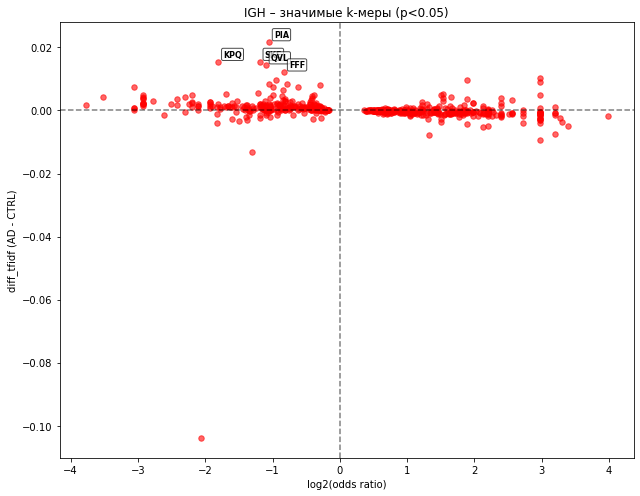


=== Обработка локуса TRA ===
Сохранено 3623 к-меров в tfidf_fisher_merged_TRA.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 LRR    0.122816    4.334244 0.339820
 RRD    0.122816    0.000000 1.000000
 GGL    0.105488    2.167057 0.463599
 GDD    0.084757    0.000000 1.000000
 AEX    0.074434    0.000000 1.000000


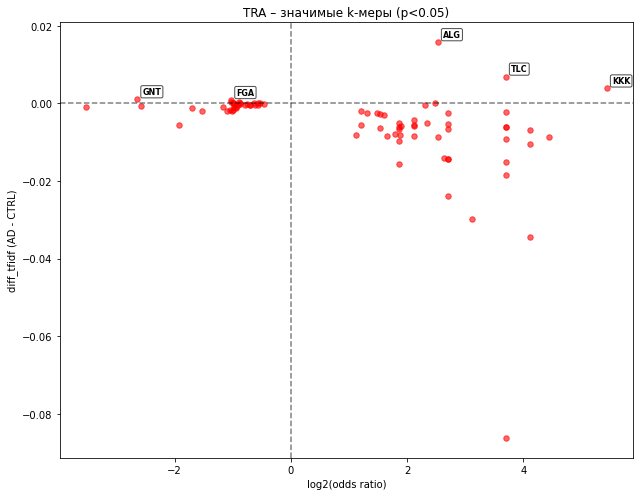


=== Обработка локуса TRB ===
Сохранено 4677 к-меров в tfidf_fisher_merged_TRB.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 FHL    0.072462    2.708249 0.068285
 HLR    0.072418    9.479677 0.002184
 HFH    0.067914    4.739677 0.011777
 KSK    0.057797    0.000000 0.568464
 TFR    0.042064    0.000000 1.000000


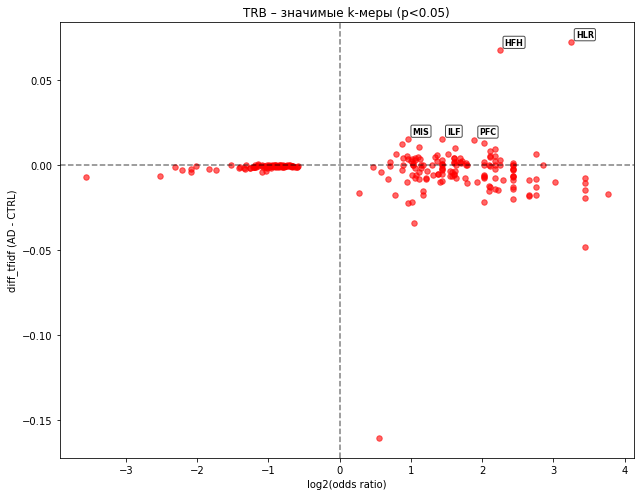


=== Обработка локуса IGK ===
Сохранено 3640 к-меров в tfidf_fisher_merged_IGK.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 HNM    0.128295    0.000000 0.427694
 NMP    0.128295    0.000000 0.427694
 SHN    0.097460    0.747312 1.000000
 TVQ    0.059454    0.000000 0.427694
 VQT    0.059454    0.000000 0.427694


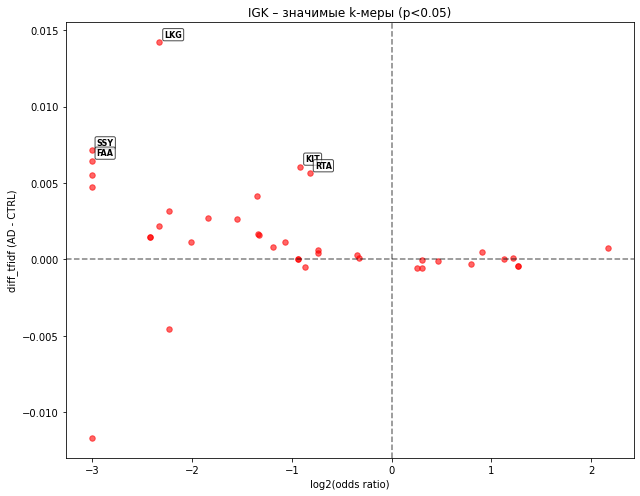


=== Обработка локуса IGL ===
Сохранено 2484 к-меров в tfidf_fisher_merged_IGL.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 FIF    0.159142         0.0 0.359489
 TFI    0.159142         0.0 0.359489
 CQP    0.096148         0.0 0.359489
 ELT    0.096148         0.0 0.359489
 LCQ    0.096148         0.0 0.359489


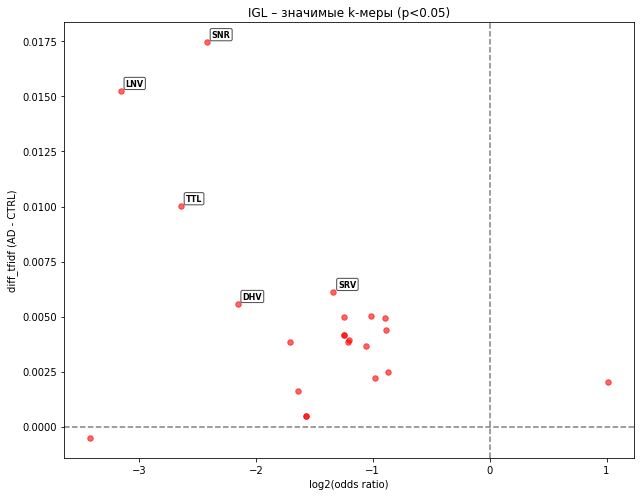

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Загрузка данных
# ============================================================
df_kmers = pd.read_csv("df_kmers.csv")                      # таблица с usage
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled.csv")  # результаты Фишера

# Исключаем k-меры со звёздочкой (если ещё не сделано)
df_kmers = df_kmers[~df_kmers['kmer'].str.contains('\*', na=False)]
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]

loci = df_kmers['locus'].unique()

# ============================================================
# 2. Функция для вычисления TF-IDF (на основе usage)
# ============================================================
def compute_tfidf_usage_based(df_kmers, locus):
    sub = df_kmers[df_kmers['locus'] == locus].copy()
    # Уникальные образцы
    all_samples = sub['sample_id'].unique()
    N_total = len(all_samples)
    
    # Словари для сбора сумм usage и числа образцов с k-мером
    kmer_stats = {}
    for kmer, group in sub.groupby('kmer'):
        # Образцы с k-мером (встречается хоть раз, usage > 0)
        samples_with = group['sample_id'].unique()
        n_samples_with = len(samples_with)
        # Средний usage по образцам, где k-мер присутствует
        mean_usage_ctrl = group[group['condition'] == 'CTRL']['usage'].mean() if (group['condition'] == 'CTRL').any() else 0
        mean_usage_ad = group[group['condition'] == 'AD']['usage'].mean() if (group['condition'] == 'AD').any() else 0
        kmer_stats[kmer] = {
            'n_samples_with': n_samples_with,
            'mean_usage_ctrl': mean_usage_ctrl,
            'mean_usage_ad': mean_usage_ad
        }
    
    results = []
    for kmer, stats in kmer_stats.items():
        n_with = stats['n_samples_with']
        idf = np.log(N_total / (n_with + 1e-9))
        tfidf_ctrl = stats['mean_usage_ctrl'] * idf
        tfidf_ad = stats['mean_usage_ad'] * idf
        results.append({
            'kmer': kmer,
            'tf_ctrl': stats['mean_usage_ctrl'],
            'tf_ad': stats['mean_usage_ad'],
            'idf': idf,
            'tfidf_ctrl': tfidf_ctrl,
            'tfidf_ad': tfidf_ad,
            'diff_tfidf': tfidf_ad - tfidf_ctrl,
            'n_samples_with': n_with
        })
    return pd.DataFrame(results)

# ============================================================
# 3. Основной цикл по локусам: объединение, сохранение, графики
# ============================================================
for locus in loci:
    print(f"\n=== Обработка локуса {locus} ===")
    
    # TF-IDF
    df_tfidf = compute_tfidf_usage_based(df_kmers, locus)
    # Данные Фишера для этого локуса
    df_fish_locus = df_fisher[df_fisher['locus'] == locus][['kmer', 'odds_ratio', 'p_value']].copy()
    # Объединяем
    df_merged = pd.merge(df_tfidf, df_fish_locus, on='kmer', how='inner')
    df_merged['log2OR'] = np.log2(df_merged['odds_ratio'].replace(0, np.nan))
    df_merged['significant'] = df_merged['p_value'] < 0.05
    
    # Сохраняем полную таблицу
    df_merged.to_csv(f"tfidf_fisher_merged_{locus}.csv", index=False)
    print(f"Сохранено {len(df_merged)} к-меров в tfidf_fisher_merged_{locus}.csv")
    
    # Топ-5 по diff_tfidf (положительные – характерны для AD)
    top_diff = df_merged.nlargest(5, 'diff_tfidf')
    print("\nТоп-5 к-меров с наибольшим приростом TF-IDF у больных (AD):")
    print(top_diff[['kmer', 'diff_tfidf', 'odds_ratio', 'p_value']].to_string(index=False))
    
    # График diff_tfidf vs log2(odds_ratio) только для значимых (p<0.05)
    sig = df_merged[df_merged['significant']].dropna(subset=['log2OR', 'diff_tfidf'])
    if not sig.empty:
        plt.figure(figsize=(9, 7))
        plt.scatter(sig['log2OR'], sig['diff_tfidf'], alpha=0.6, s=30, color='red')
        # Подписываем топ-5 по абсолютной разнице TF-IDF среди значимых
        top5_abs = sig.nlargest(5, 'diff_tfidf').copy()
        for _, row in top5_abs.iterrows():
            plt.annotate(row['kmer'],
                         xy=(row['log2OR'], row['diff_tfidf']),
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=8, weight='bold',
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
        plt.axhline(0, color='black', linestyle='--', alpha=0.5)
        plt.axvline(0, color='black', linestyle='--', alpha=0.5)
        plt.xlabel('log2(odds ratio)')
        plt.ylabel('diff_tfidf (AD - CTRL)')
        plt.title(f'{locus} – значимые k-меры (p<0.05)')
        plt.tight_layout()
        plt.savefig(f"diff_tfidf_vs_log2OR_{locus}.png", dpi=150)
        plt.show()
        plt.close()
    else:
        print("Нет значимых к-меров для построения графика.")

1. Что такое TF-IDF в нашем контексте

    TF (Term Frequency) – средняя частота (значение usage) k-мера в образцах группы (CTRL или AD).
    Если к-мер отсутствует в образце, его вклад в TF равен 0.
    Высокий TF означает, что в среднем к-мер встречается часто в образцах данной группы (обильно представлен).

    IDF (Inverse Document Frequency) – мера редкости k-мера во всей выборке (CTRL+AD).
    idf = log(общее число образцов / число образцов, где k-мер присутствует).
    Редкие к-меры (встречаются в малом числе образцов) получают высокий IDF, частые – низкий.

    TF-IDF = TF * IDF.
    Высокое значение означает, что к-мер часто встречается в группе (высокий TF) и при этом он редок в общей выборке (высокий IDF).
    Это показывает важность или специфичность к-мера для группы.

    diff_tfidf = TF-IDF(AD) - TF-IDF(CTRL).
    Положительное значение – к-мер более характерен для больных (AD), отрицательное – для здоровых (CTRL).

2. Как интерпретировать полученные цифры

Рассмотрим топ-5 к-меров по diff_tfidf для какого-нибудь локуса, например, IGH. Допустим, вы получили:
kmer	diff_tfidf	odds_ratio	p_value
ASP	0.35	3.49	4.5e-54
SPT	0.28	3.42	2.1e-50
PTS	0.22	3.31	1.4e-42
...	...	...	...

    ASP имеет высокий положительный diff_tfidf (0.35) и высокий odds_ratio (3.49), p-value очень маленькое.
    Это означает, что ASP:

        Часто встречается у больных (высокий TF в AD).

        Редок в общей выборке (высокий IDF) – возможно, почти отсутствует у здоровых.

        Вывод: ASP – сильный потенциальный маркер заболевания.

    Если бы у какого-то к-мера был высокий diff_tfidf, но odds_ratio около 1 (например, 1.1), это значило бы, что он не различается по факту наличия/отсутствия между группами, но его обилие (usage) выше у больных. Такой к-мер мог бы быть связан с экспрессией (например, клонов, которые у больных более представлены количественно, но не качественно).

3. График diff_tfidf vs log2(odds_ratio)

На построенном вами графике (для значимых к-меров) можно выделить несколько зон:

    Правый верхний квадрант (log2OR > 0, diff_tfidf > 0) – к-меры, характерные для больных и по наличию, и по специфичности. Самые интересные кандидаты.

    Левый нижний квадрант (log2OR < 0, diff_tfidf < 0) – к-меры, характерные для здоровых.

    Правый нижний квадрант (log2OR > 0, diff_tfidf < 0) – парадоксальная ситуация: к-мер чаще встречается у больных (OR>1), но его TF-IDF выше у здоровых. Это возможно, если у здоровых к-мер встречается редко, но с очень высокой частотой (usage) в тех образцах, где он есть. Такие случаи редки и требуют проверки.

    Левый верхний квадрант (log2OR < 0, diff_tfidf > 0) – к-мер чаще у здоровых, но важнее для больных – тоже аномалия.

Ваши топ-5 по diff_tfidf, скорее всего, окажутся в правом верхнем квадранте.
4. Сравнение с тестом Фишера

Тест Фишера смотрит только на наличие/отсутствие к-мера в образце (бинарно).
TF-IDF учитывает частоту (usage) и редкость. Поэтому:

    К-меры, значимые по Фишеру с высоким OR, но низким diff_tfidf, могут быть редкими, но при этом их средняя частота у больных не сильно выше, чем у здоровых (или они встречаются в очень малом числе образцов, что даёт низкий TF).

    К-меры с высоким diff_tfidf, но незначимые по Фишеру (p ≥ 0.05), могут иметь умеренный OR, но высокую частоту у больных и низкую IDF. Их стоит рассматривать как потенциально важные, но требующие подтверждения на большей выборке.

5. Практические рекомендации

    Для отбора кандидатов используйте одновременно два критерия:

        p_value < 0.05 (Фишер)

        diff_tfidf > 0 и/или odds_ratio > 1

        Дополнительно можно отфильтровать по минимальному TF в AD (например, >0.001), чтобы исключить очень редкие к-меры с низким охватом.

    Визуализируйте распределение usage для топ-к-меров (гистограммы, boxplot), чтобы увидеть, насколько сильно отличается средняя частота между группами.

    Для углублённого анализа выберите 5–10 к-меров с максимальным diff_tfidf и высоким odds_ratio. Проверьте их:

        расположение в CDR3 (как вы делали ранее)

        ассоциацию с V/D/J генами

        наличие в известных базах (IMGT, ImmuneAccess)

Мы добавили в код несколько полезных расширений из пункта 6:

    Пересечение топ-5 по diff_tfidf и топ-5 по odds_ratio – выводит общие к-меры, которые одновременно являются наиболее специфичными для больных и имеют наибольший odds ratio.

    Корреляция Пирсона между diff_tfidf и log2(odds_ratio) для значимых к-меров – позволяет понять, насколько эти две метрики согласованы.

    График с цветом по -log10(p-value) – вместо одноцветных точек использует цветовую шкалу, показывающую значимость.

    Фильтрация по минимальному TF в AD – исключает к-меры с очень низкой средней частотой у больных (например, <0.001), чтобы убрать шум.

    Дополнительная визуализация: top-5 по diff_tfidf – гистограммы usage – помогает увидеть распределение частот для отобранных к-меров.


=== Обработка локуса IGH ===
Сохранено 2543 к-меров в tf_idf/tfidf_fisher_merged_IGH.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 IIQ    0.039552    0.729558 0.788540
 QQK    0.030833    1.313230 0.733225
 PIA    0.021668    0.481475 0.039682
 PTE    0.021668    2.188744 0.304129
 XKF    0.021668    0.000000 1.000000

Пересечение топ-5 по diff_tfidf и топ-5 по odds_ratio: нет

Корреляция Пирсона diff_tfidf vs log2OR: r=-0.015, p=7.829e-01


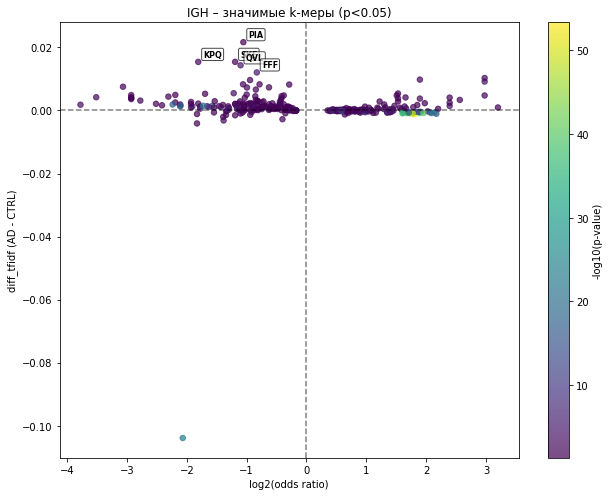


Визуализация распределений usage для топ-5 по diff_tfidf:


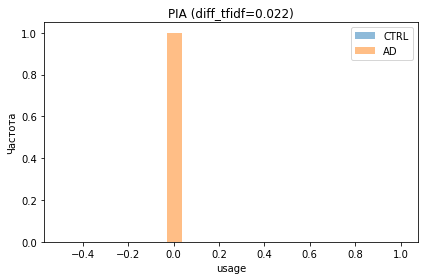

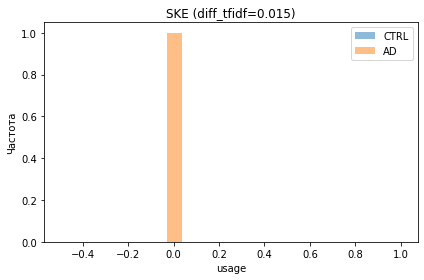

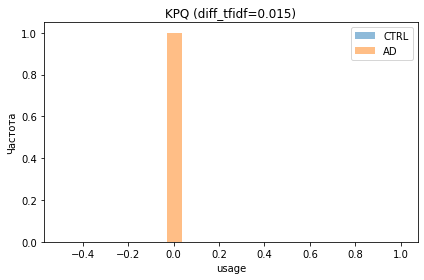

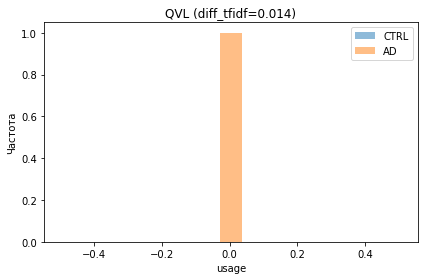

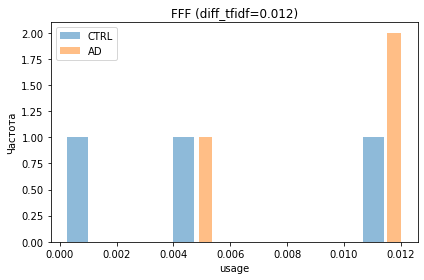


=== Обработка локуса TRA ===
Сохранено 2224 к-меров в tf_idf/tfidf_fisher_merged_TRA.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 LRR    0.122816    4.334244 0.339820
 RRD    0.122816    0.000000 1.000000
 GGL    0.105488    2.167057 0.463599
 GDD    0.084757    0.000000 1.000000
 AEX    0.074434    0.000000 1.000000

Пересечение топ-5 по diff_tfidf и топ-5 по odds_ratio: нет

Корреляция Пирсона diff_tfidf vs log2OR: r=-0.394, p=1.404e-03


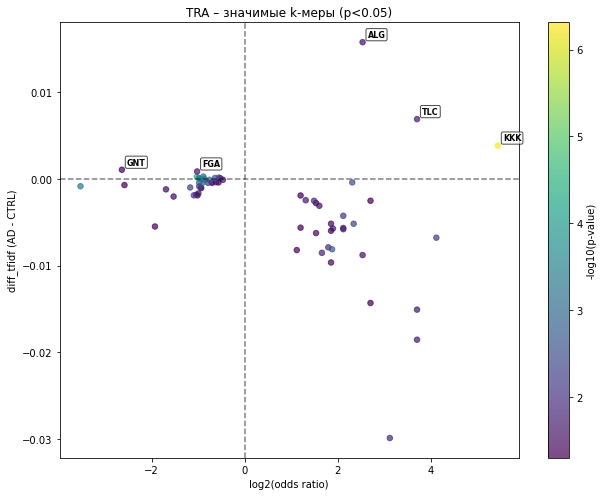


Визуализация распределений usage для топ-5 по diff_tfidf:


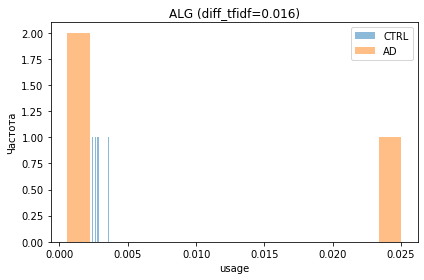

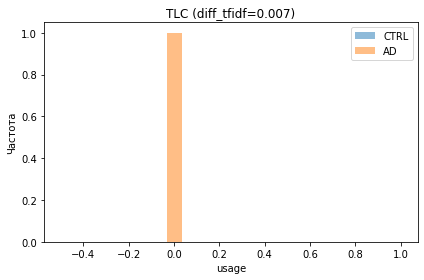

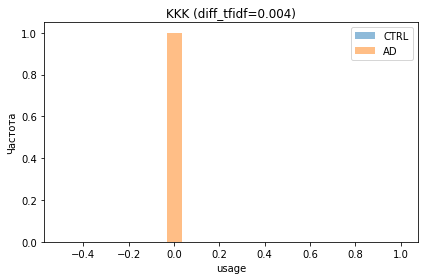

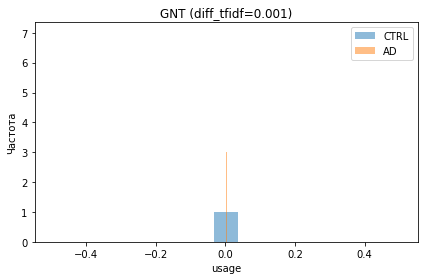

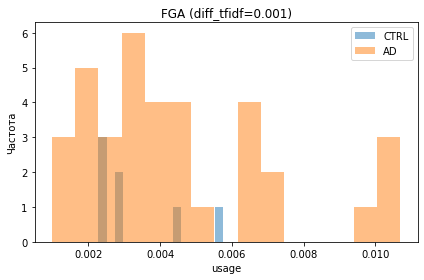


=== Обработка локуса TRB ===
Сохранено 2713 к-меров в tf_idf/tfidf_fisher_merged_TRB.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 FHL    0.072462    2.708249 0.068285
 HLR    0.072418    9.479677 0.002184
 HFH    0.067914    4.739677 0.011777
 KSK    0.057797    0.000000 0.568464
 TFR    0.042064    0.000000 1.000000

Пересечение топ-5 по diff_tfidf и топ-5 по odds_ratio: {'HLR'}

Корреляция Пирсона diff_tfidf vs log2OR: r=0.066, p=3.747e-01


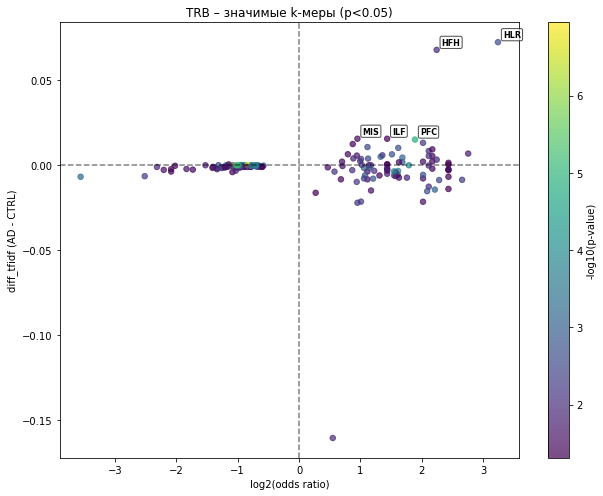


Визуализация распределений usage для топ-5 по diff_tfidf:


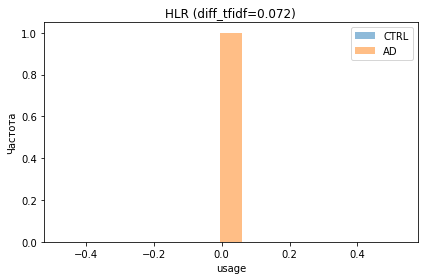

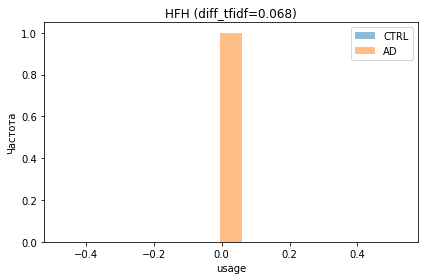

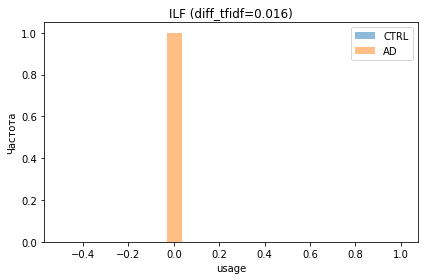

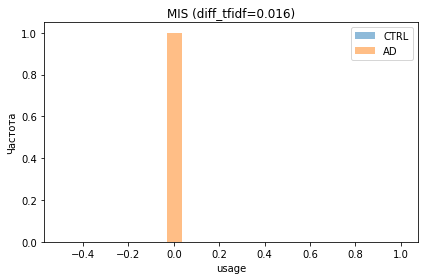

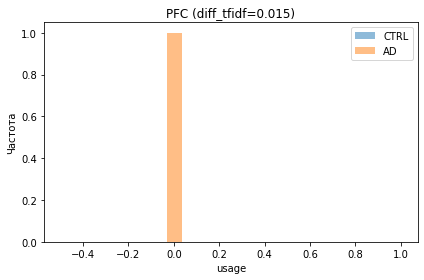


=== Обработка локуса IGK ===
Сохранено 1725 к-меров в tf_idf/tfidf_fisher_merged_IGK.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 HNM    0.128295    0.000000 0.427694
 NMP    0.128295    0.000000 0.427694
 SHN    0.097460    0.747312 1.000000
 TVQ    0.059454    0.000000 0.427694
 VQT    0.059454    0.000000 0.427694

Пересечение топ-5 по diff_tfidf и топ-5 по odds_ratio: нет

Корреляция Пирсона diff_tfidf vs log2OR: r=-0.282, p=1.117e-01


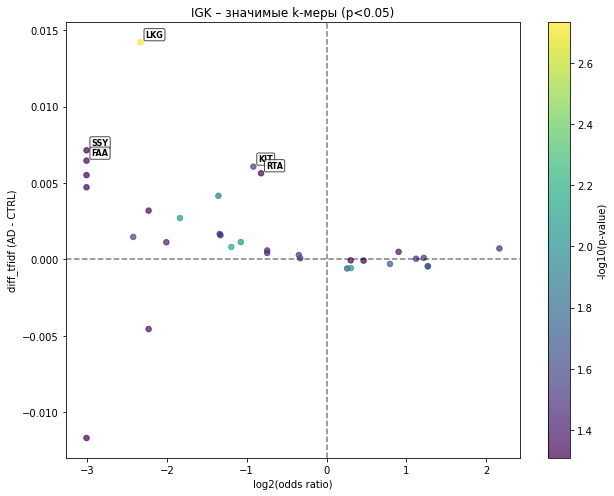


Визуализация распределений usage для топ-5 по diff_tfidf:


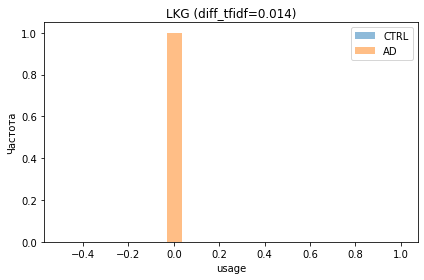

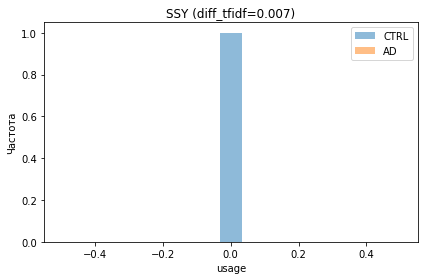

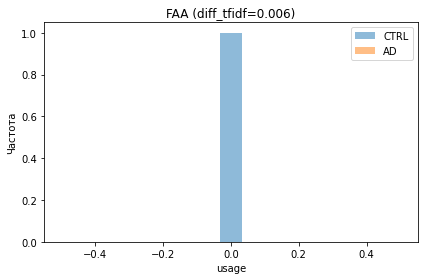

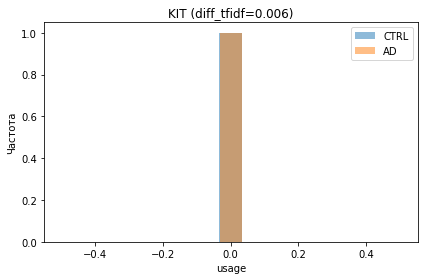

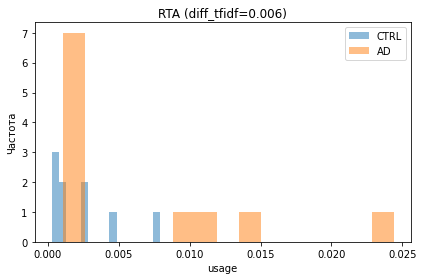


=== Обработка локуса IGL ===
Сохранено 1266 к-меров в tf_idf/tfidf_fisher_merged_IGL.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (AD):
kmer  diff_tfidf  odds_ratio  p_value
 FIF    0.159142         0.0 0.359489
 TFI    0.159142         0.0 0.359489
 CQP    0.096148         0.0 0.359489
 ELT    0.096148         0.0 0.359489
 LCQ    0.096148         0.0 0.359489

Пересечение топ-5 по diff_tfidf и топ-5 по odds_ratio: нет

Корреляция Пирсона diff_tfidf vs log2OR: r=-0.416, p=5.428e-02


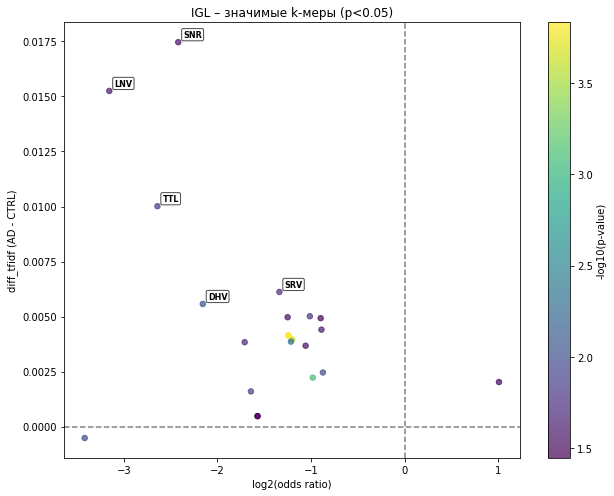


Визуализация распределений usage для топ-5 по diff_tfidf:


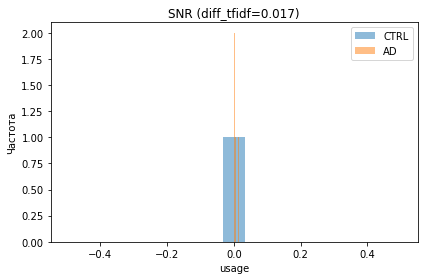

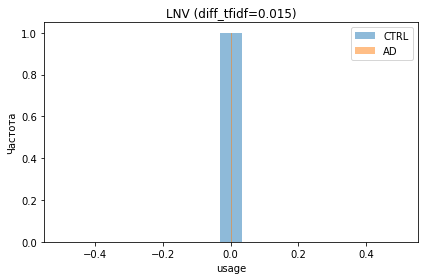

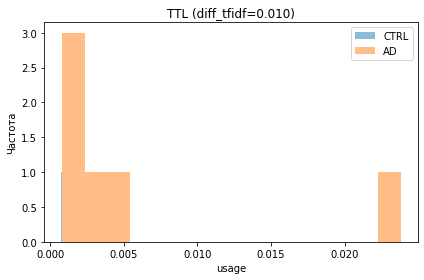

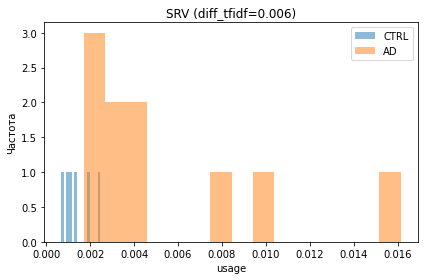

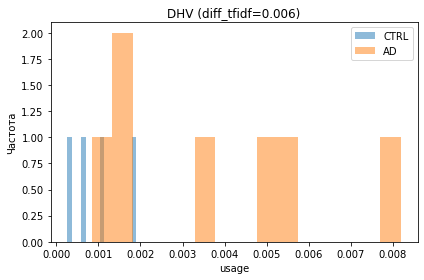

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

# Создаём папку для результатов TF-IDF
output_dir = "tf_idf"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 1. Загрузка данных
# ============================================================
df_kmers = pd.read_csv("df_kmers.csv")                      # таблица с usage
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled.csv")  # результаты Фишера

# Исключаем k-меры со звёздочкой
df_kmers = df_kmers[~df_kmers['kmer'].str.contains('\*', na=False)]
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]

loci = df_kmers['locus'].unique()

# ============================================================
# 2. Функция для вычисления TF-IDF (на основе usage)
# ============================================================
def compute_tfidf_usage_based(df_kmers, locus):
    sub = df_kmers[df_kmers['locus'] == locus].copy()
    all_samples = sub['sample_id'].unique()
    N_total = len(all_samples)
    
    kmer_stats = {}
    for kmer, group in sub.groupby('kmer'):
        samples_with = group['sample_id'].unique()
        n_samples_with = len(samples_with)
        mean_usage_ctrl = group[group['condition'] == 'CTRL']['usage'].mean() if (group['condition'] == 'CTRL').any() else 0
        mean_usage_ad = group[group['condition'] == 'AD']['usage'].mean() if (group['condition'] == 'AD').any() else 0
        kmer_stats[kmer] = {
            'n_samples_with': n_samples_with,
            'mean_usage_ctrl': mean_usage_ctrl,
            'mean_usage_ad': mean_usage_ad
        }
    
    results = []
    for kmer, stats in kmer_stats.items():
        n_with = stats['n_samples_with']
        idf = np.log(N_total / (n_with + 1e-9))
        tfidf_ctrl = stats['mean_usage_ctrl'] * idf
        tfidf_ad = stats['mean_usage_ad'] * idf
        results.append({
            'kmer': kmer,
            'tf_ctrl': stats['mean_usage_ctrl'],
            'tf_ad': stats['mean_usage_ad'],
            'idf': idf,
            'tfidf_ctrl': tfidf_ctrl,
            'tfidf_ad': tfidf_ad,
            'diff_tfidf': tfidf_ad - tfidf_ctrl,
            'n_samples_with': n_with
        })
    return pd.DataFrame(results)

# ============================================================
# 3. Основной цикл по локусам
# ============================================================
for locus in loci:
    print(f"\n=== Обработка локуса {locus} ===")
    
    # TF-IDF
    df_tfidf = compute_tfidf_usage_based(df_kmers, locus)
    # Данные Фишера для этого локуса
    df_fish_locus = df_fisher[df_fisher['locus'] == locus][['kmer', 'odds_ratio', 'p_value']].copy()
    # Объединяем
    df_merged = pd.merge(df_tfidf, df_fish_locus, on='kmer', how='inner')
    df_merged['log2OR'] = np.log2(df_merged['odds_ratio'].replace(0, np.nan))
    df_merged['significant'] = df_merged['p_value'] < 0.05
    # Фильтр по минимальному TF в AD (например, 0.001)
    min_tf_ad = 0.001
    df_merged = df_merged[df_merged['tf_ad'] >= min_tf_ad]
    
    # Сохраняем полную таблицу в папку tf_idf
    csv_path = os.path.join(output_dir, f"tfidf_fisher_merged_{locus}.csv")
    df_merged.to_csv(csv_path, index=False)
    print(f"Сохранено {len(df_merged)} к-меров в {csv_path}")
    
    # Топ-5 по diff_tfidf
    top_diff = df_merged.nlargest(5, 'diff_tfidf')
    print("\nТоп-5 к-меров с наибольшим приростом TF-IDF у больных (AD):")
    print(top_diff[['kmer', 'diff_tfidf', 'odds_ratio', 'p_value']].to_string(index=False))
    
    # Пересечение топ-5 по diff_tfidf и топ-5 по odds_ratio
    top_or = df_merged.nlargest(5, 'odds_ratio')
    common = set(top_diff['kmer']).intersection(set(top_or['kmer']))
    print("\nПересечение топ-5 по diff_tfidf и топ-5 по odds_ratio:", common if common else "нет")
    
    # Значимые к-меры
    sig = df_merged[df_merged['significant']].dropna(subset=['log2OR', 'diff_tfidf'])
    if not sig.empty:
        # Корреляция Пирсона
        if len(sig) > 1:
            corr, p_corr = pearsonr(sig['diff_tfidf'], sig['log2OR'])
            print(f"\nКорреляция Пирсона diff_tfidf vs log2OR: r={corr:.3f}, p={p_corr:.3e}")
        
        # График с цветом по -log10(p)
        plt.figure(figsize=(9, 7))
        sc = plt.scatter(sig['log2OR'], sig['diff_tfidf'], 
                         c=-np.log10(sig['p_value']+1e-300), 
                         cmap='viridis', alpha=0.7, s=30)
        plt.colorbar(sc, label='-log10(p-value)')
        # Подписываем топ-5 по diff_tfidf
        top5_abs = sig.nlargest(5, 'diff_tfidf').copy()
        for _, row in top5_abs.iterrows():
            plt.annotate(row['kmer'],
                         xy=(row['log2OR'], row['diff_tfidf']),
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=8, weight='bold',
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
        plt.axhline(0, color='black', linestyle='--', alpha=0.5)
        plt.axvline(0, color='black', linestyle='--', alpha=0.5)
        plt.xlabel('log2(odds ratio)')
        plt.ylabel('diff_tfidf (AD - CTRL)')
        plt.title(f'{locus} – значимые k-меры (p<0.05)')
        plt.tight_layout()
        plot_path = os.path.join(output_dir, f"diff_tfidf_vs_log2OR_{locus}.png")
        plt.savefig(plot_path, dpi=150)
        plt.show()
        plt.close()
        
        # Дополнительная визуализация: гистограммы usage для топ-5 по diff_tfidf
        print("\nВизуализация распределений usage для топ-5 по diff_tfidf:")
        for kmer in top5_abs['kmer'].values:
            data = df_kmers[(df_kmers['locus'] == locus) & (df_kmers['kmer'] == kmer)]
            fig, ax = plt.subplots(figsize=(6,4))
            ax.hist(data[data['condition']=='CTRL']['usage'], bins=15, alpha=0.5, label='CTRL')
            ax.hist(data[data['condition']=='AD']['usage'], bins=15, alpha=0.5, label='AD')
            ax.set_xlabel('usage')
            ax.set_ylabel('Частота')
            diff_val = top5_abs[top5_abs['kmer']==kmer]['diff_tfidf'].values[0]
            ax.set_title(f'{kmer} (diff_tfidf={diff_val:.3f})')
            ax.legend()
            plt.tight_layout()
            hist_path = os.path.join(output_dir, f"usage_{locus}_{kmer}.png")
            plt.savefig(hist_path, dpi=150)
            plt.show()
            plt.close()
    else:
        print("Нет значимых к-меров для построения графиков.")

# анализ значимых к-меров

анализ позиций значимых k-меров в CDR3 с нормировкой по длине, а также подготовили данные для последующего изучения расположения в V/D/J сегментах. Теперь у вас есть таблица kmer_cdr3_positions.csv и гистограммы для топ-к-меров, которые показывают, есть ли смещение в распределении (например, кластеризация в начале или в конце CDR3).

фильтрация по AD, productive=T, pgen_log > -40, использование значимых к-меров из теста Фишера (p<0.05), поиск позиции в CDR3, нормировка по длине CDR3, визуализация распределений для топ-5 к-меров. + расчёт позиций в V-гене

In [32]:
df_original['v_sequence_start']

0        32.0
1        83.0
2        80.0
3        83.0
4        81.0
         ... 
16167     1.0
16168     1.0
16169     1.0
16170     1.0
16171     1.0
Name: v_sequence_start, Length: 16172, dtype: float64

После фильтрации: 2811 записей
Найдено значимых k-меров: 1162
Обработано 0 из 1162 k-меров
Обработано 50 из 1162 k-меров
Обработано 100 из 1162 k-меров
Обработано 150 из 1162 k-меров
Обработано 200 из 1162 k-меров
Обработано 250 из 1162 k-меров
Обработано 300 из 1162 k-меров
Обработано 350 из 1162 k-меров
Обработано 400 из 1162 k-меров
Обработано 450 из 1162 k-меров
Обработано 500 из 1162 k-меров
Обработано 550 из 1162 k-меров
Обработано 600 из 1162 k-меров
Обработано 650 из 1162 k-меров
Обработано 700 из 1162 k-меров
Обработано 750 из 1162 k-меров
Обработано 800 из 1162 k-меров
Обработано 850 из 1162 k-меров
Обработано 900 из 1162 k-меров
Обработано 950 из 1162 k-меров
Обработано 1000 из 1162 k-меров
Обработано 1050 из 1162 k-меров
Обработано 1100 из 1162 k-меров
Обработано 1150 из 1162 k-меров
Собрано записей: 7006
Сохранено в kmer_cdr3_positions.csv

Топ-5 k-меров по числу вхождений в CDR3:
ASS: 415
TQY: 120
EQF: 105
NEQ: 82
GYT: 79


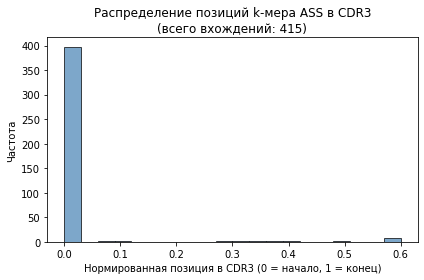

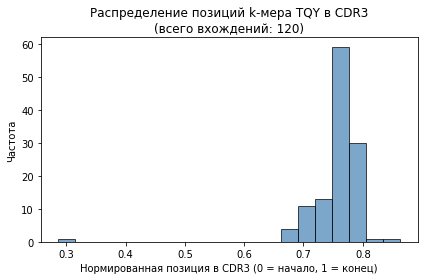

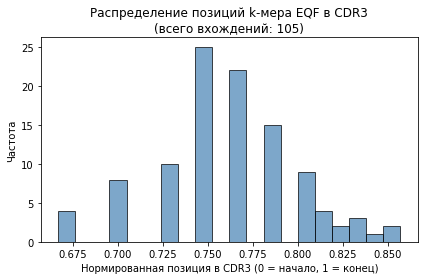

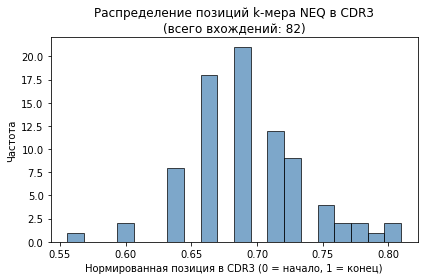

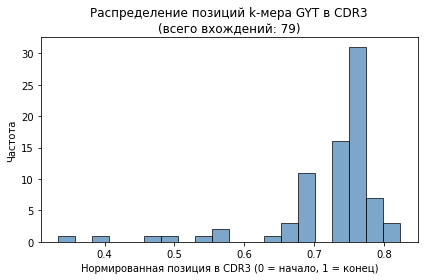

Сводная статистика сохранена в kmer_cdr3_summary.csv


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Загрузка исходных данных (предполагается, что df_original уже загружен)
# ============================================================
df_original = pd.read_csv('data_filtered.csv')

# Фильтрация: только AD, продуктивные, pgen_log > -40
df_filtered = df_original[
    (df_original['condition'] == 'AD') &
    (df_original['productive'] == 'T') &
    (df_original['pgen_log'] > -40)
].copy()
print(f"После фильтрации: {len(df_filtered)} записей")

# ============================================================
# 2. Загрузка значимых k-меров из результатов теста Фишера
# ============================================================
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled.csv")
# Удаляем к-меры со звёздочкой
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]
# Берём только значимые (p < 0.05)
sig_kmers = df_fisher[df_fisher['p_value'] < 0.05]['kmer'].unique()
print(f"Найдено значимых k-меров: {len(sig_kmers)}")
# Для ускорения, если к-меров очень много, можно ограничиться первыми N (например, 100)
# sig_kmers = sig_kmers[:100]

# ============================================================
# 3. Функция для поиска позиции k-мера в CDR3 и нормировки
# ============================================================
def get_cdr3_position_info(kmer, cdr3_seq):
    """
    Возвращает словарь с информацией о первом вхождении k-мера в cdr3_seq.
    Параметры:
        kmer (str): искомый трипептид
        cdr3_seq (str): последовательность CDR3
    Возвращает:
        dict или None, если kmer не найден
    """
    if pd.isna(cdr3_seq) or not isinstance(cdr3_seq, str):
        return None
    pos = cdr3_seq.find(kmer)
    if pos == -1:
        return None
    cdr3_len = len(cdr3_seq)
    norm_pos = pos / cdr3_len if cdr3_len > 0 else np.nan
    return {
        'cdr3_start_index': pos,
        'cdr3_len': cdr3_len,
        'norm_position': norm_pos
    }

# ============================================================
# 4. Функция для определения принадлежности к V/D/J сегментам
#    (предполагаем, что координаты даны в аминокислотных позициях
#     относительно sequence_aa и колонки называются v_start, v_end и т.д.)
#    Если таких колонок нет, функция вернёт None.
# ============================================================
def get_gene_region(kmer, start_pos_in_seq, v_start, v_end, d_start, d_end, j_start, j_end):
    """
    Определяет, в какой области (V/D/J/CDR3) находится k-мер.
    start_pos_in_seq - индекс начала k-мера в sequence_aa (0-based).
    Возвращает строку: 'V', 'D', 'J', 'CDR3' или 'other'.
    """
    # Здесь start_pos_in_seq - это позиция первого символа k-мера в полной последовательности.
    # Для упрощения мы не используем эту функцию в основной цикл, так как координаты V/D/J часто заданы в нуклеотидных координатах.
    # Если вы предоставите точные названия колонок и формат, я допишу.
    # Пока заглушка.
    return 'unknown'

# ============================================================
# 5. Основной цикл сбора данных о позициях в CDR3
# ============================================================
records = []
# Преобразуем DataFrame в список словарей для быстрого доступа
rows = df_filtered.to_dict('records')

# Для отслеживания прогресса
total_kmers = len(sig_kmers)
for i, kmer in enumerate(sig_kmers):
    if i % 50 == 0:
        print(f"Обработано {i} из {total_kmers} k-меров")
    for row in rows:
        seq_aa = row.get('sequence_aa')
        cdr3_aa = row.get('cdr3_aa')
        # Быстрая проверка: если k-мер не содержится в полной последовательности, пропускаем
        if kmer not in seq_aa:
            continue
        info = get_cdr3_position_info(kmer, cdr3_aa)
        if info is not None:
            records.append({
                'kmer': kmer,
                'sample_id': row.get('sample_id'),
                'sequence_id': row.get('sequence_id', row.get('sample_id')),  # если нет sequence_id, используем sample_id
                'locus': row.get('locus'),
                'cdr3_seq': cdr3_aa,
                'cdr3_start_index': info['cdr3_start_index'],
                'cdr3_len': info['cdr3_len'],
                'norm_position': info['norm_position']
            })

# Создаём DataFrame с позициями в CDR3
df_cdr3_positions = pd.DataFrame(records)
print(f"Собрано записей: {len(df_cdr3_positions)}")

# Сохраняем
df_cdr3_positions.to_csv("kmer_cdr3_positions.csv", index=False)
print("Сохранено в kmer_cdr3_positions.csv")

# ============================================================
# 6. Анализ распределений: гистограммы для топ-5 к-меров (по частоте в CDR3)
# ============================================================
kmer_counts = df_cdr3_positions['kmer'].value_counts().head(5)
print("\nТоп-5 k-меров по числу вхождений в CDR3:")
for kmer, cnt in kmer_counts.items():
    print(f"{kmer}: {cnt}")

for kmer in kmer_counts.index:
    subset = df_cdr3_positions[df_cdr3_positions['kmer'] == kmer]['norm_position'].dropna()
    if len(subset) == 0:
        continue
    plt.figure(figsize=(6,4))
    plt.hist(subset, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel('Нормированная позиция в CDR3 (0 = начало, 1 = конец)')
    plt.ylabel('Частота')
    plt.title(f'Распределение позиций k-мера {kmer} в CDR3\n(всего вхождений: {len(subset)})')
    plt.tight_layout()
    plt.savefig(f"cdr3_position_{kmer}.png", dpi=150)
    plt.show()
    plt.close()

# ============================================================
# 7. Дополнительно: сводная статистика для всех к-меров
# ============================================================
summary = df_cdr3_positions.groupby('kmer')['norm_position'].agg(['mean', 'std', 'count']).reset_index()
summary = summary.rename(columns={'mean': 'mean_norm_pos', 'std': 'std_norm_pos', 'count': 'n_cdr3_hits'})
summary.to_csv("kmer_cdr3_summary.csv", index=False)
print("Сводная статистика сохранена в kmer_cdr3_summary.csv")

После фильтрации: 2811 записей, из них уникальных CDR3: 2530
Всего значимых к-меров: 1162


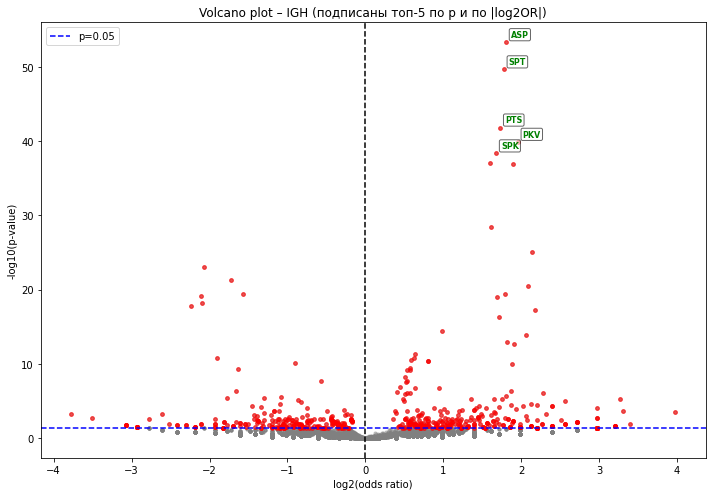

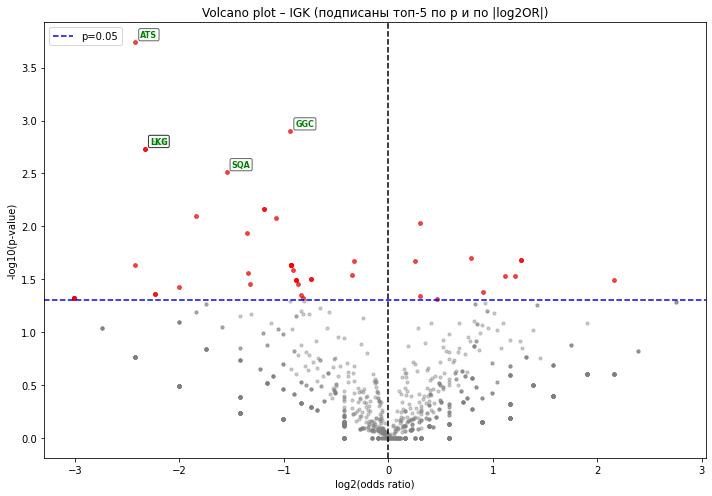

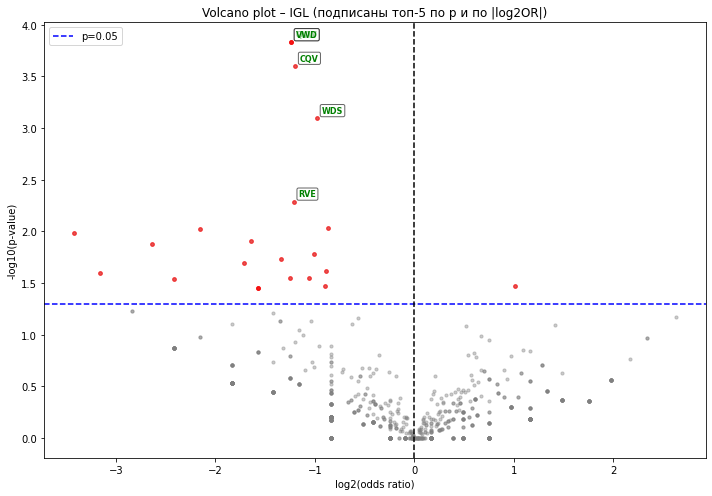

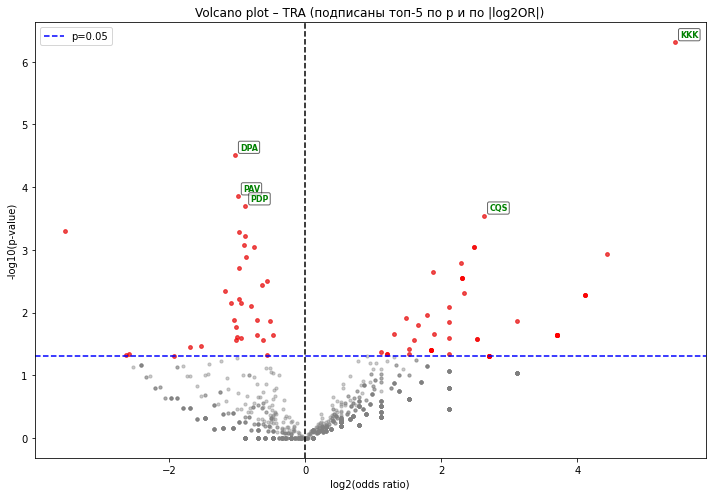

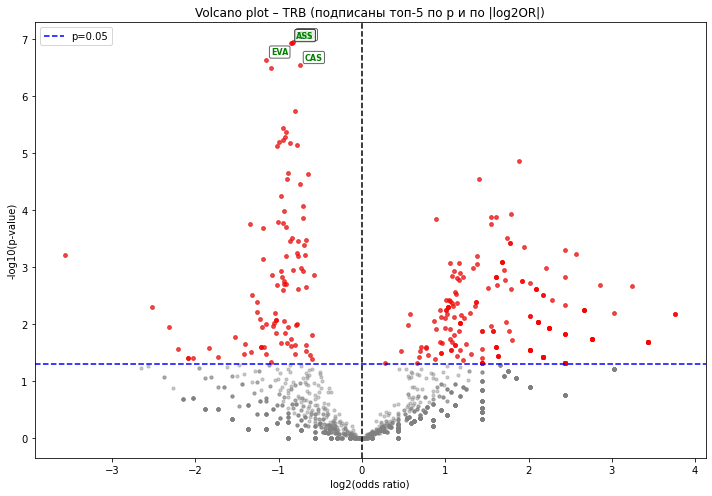

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
import os

# Создаём папки для результатов
os.makedirs("cdr3", exist_ok=True)
os.makedirs("fishertest", exist_ok=True)

df_original = pd.read_csv('data_filtered.csv')


# Фильтрация: только AD, продуктивные, pgen_log > -40
df_ad = df_original[
    (df_original['condition'] == 'AD') &
    (df_original['productive'] == 'T') &
    (df_original['pgen_log'] > -40)
].copy()
print(f"После фильтрации: {len(df_ad)} записей, из них уникальных CDR3: {df_ad['cdr3_aa'].nunique()}")


# Загрузка результатов Фишера (предполагается, что файл уже есть)
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled.csv")
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]
df_fisher['significant'] = df_fisher['p_value'] < 0.05
sig_kmers = df_fisher[df_fisher['significant']]['kmer'].unique()
print(f"Всего значимых к-меров: {len(sig_kmers)}")

# Построение volcano plot с подписями топ-5 по p-value и по |log2OR|
for locus in df_fisher['locus'].unique():
    sub = df_fisher[df_fisher['locus'] == locus].copy()
    sub['log2OR'] = np.log2(sub['odds_ratio'].replace(0, np.nan))
    sub['neg_log10_p'] = -np.log10(sub['p_value'] + 1e-300)
    
    # Удаляем NaN
    sub_clean = sub.dropna(subset=['log2OR', 'neg_log10_p'])
    if sub_clean.empty:
        print(f"Нет данных для локуса {locus} после удаления NaN")
        continue
    
    # Топ-5 по наименьшему p-value (наибольшему -log10p)
    top_p = sub_clean.nlargest(min(5, len(sub_clean)), 'neg_log10_p')
    # Топ-5 по абсолютному log2OR
    top_or_indices = sub_clean['log2OR'].abs().nlargest(min(5, len(sub_clean))).index
    top_or = sub_clean.loc[top_or_indices]
    
    plt.figure(figsize=(10, 7))
    # Все точки
    plt.scatter(sub_clean['log2OR'], sub_clean['neg_log10_p'], alpha=0.4, s=10, color='gray')
    # Значимые выделяем красным
    sig = sub_clean[sub_clean['significant']]
    if not sig.empty:
        plt.scatter(sig['log2OR'], sig['neg_log10_p'], alpha=0.6, s=15, color='red')
    
    # Подписи топ-5 по p-value (зелёные)
    for _, row in top_p.iterrows():
        plt.annotate(row['kmer'], xy=(row['log2OR'], row['neg_log10_p']),
                     xytext=(5,5), textcoords='offset points',
                     fontsize=8, color='green', weight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
    # Подписи топ-5 по |log2OR| (синие)
    for _, row in top_or.iterrows():
        plt.annotate(row['kmer'], xy=(row['log2OR'], row['neg_log10_p']),
                     xytext=(-10,-5), textcoords='offset points',
                     fontsize=8, color='blue', weight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
    
    plt.axhline(-np.log10(0.05), linestyle='--', color='blue', label='p=0.05')
    plt.axvline(0, linestyle='--', color='black')
    plt.xlabel('log2(odds ratio)')
    plt.ylabel('-log10(p-value)')
    plt.title(f'Volcano plot – {locus} (подписаны топ-5 по p и по |log2OR|)')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(f"fishertest/volcano_{locus}_annotated.png", dpi=150)
    plt.show()
    plt.close()

. Анализ позиций значимых к-меров в CDR3 (только для AD)

Для каждого значимого к-мера ищем все вхождения в колонке cdr3_aa (без пропусков). Записываем стартовую позицию (0‑индекс), длину CDR3, нормированную позицию = позиция / длина. Также можно добавить информацию о том, в какой части гена находится к-мер (V/D/J), но для этого нужны координаты в полной последовательности. Пока ограничимся CDR3.

In [18]:
# Словарь для сбора данных о позициях
records = []
for kmer in sig_kmers:
    # Ищем строки, где cdr3_aa содержит данный k-мер
    mask = df_ad['cdr3_aa'].str.contains(kmer, na=False)
    if not mask.any():
        continue
    for idx, row in df_ad[mask].iterrows():
        cdr3 = row['cdr3_aa']
        start = cdr3.find(kmer)
        if start == -1:
            continue
        cdr3_len = len(cdr3)
        norm_pos = start / cdr3_len if cdr3_len > 0 else np.nan
        records.append({
            'kmer': kmer,
            'sample_id': row.get('sample_id'),
            'locus': row.get('locus'),
            'cdr3_seq': cdr3,
            'cdr3_len': cdr3_len,
            'start_index': start,
            'norm_position': norm_pos
        })

df_cdr3 = pd.DataFrame(records)
print(f"Собрано записей: {len(df_cdr3)}")
df_cdr3.to_csv("cdr3/kmer_cdr3_positions.csv", index=False)

# Сводная статистика по каждому к-меру (средняя позиция, количество вхождений)
summary = df_cdr3.groupby('kmer').agg(
    n_hits=('kmer', 'count'),
    mean_norm_pos=('norm_position', 'mean'),
    std_norm_pos=('norm_position', 'std')
).reset_index()
summary.to_csv("cdr3/kmer_cdr3_summary.csv", index=False)

Собрано записей: 7006


для одного к-мера (например, первого из топ-5 по частоте)


Пример для к-мера: ASS
  Всего вхождений: 415
  Первые 5 записей:
            cdr3_seq  start_index  cdr3_len  norm_position
4986       ASSLGGEQY            0         9            0.0
4987    ASSLSGGNTEAF            0        12            0.0
4988  ASSLWIGLASYEQY            0        14            0.0
4989   ASSPSATGWGGYT            0        13            0.0
4990   ASSLPRGVNTGYT            0        13            0.0


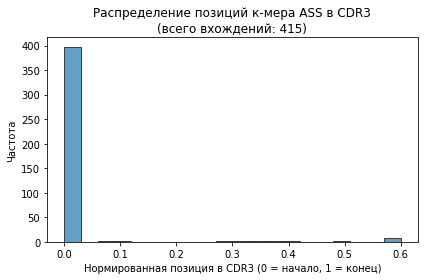

In [19]:
# Выберем к-мер с наибольшим числом вхождений
top_kmer = summary.nlargest(1, 'n_hits')['kmer'].iloc[0]
print(f"\nПример для к-мера: {top_kmer}")
sub = df_cdr3[df_cdr3['kmer'] == top_kmer]
print(f"  Всего вхождений: {len(sub)}")
print("  Первые 5 записей:")
print(sub[['cdr3_seq', 'start_index', 'cdr3_len', 'norm_position']].head())

# Визуализация распределения нормированных позиций для этого к-мера
plt.figure(figsize=(6,4))
plt.hist(sub['norm_position'], bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Нормированная позиция в CDR3 (0 = начало, 1 = конец)')
plt.ylabel('Частота')
plt.title(f'Распределение позиций к-мера {top_kmer} в CDR3\n(всего вхождений: {len(sub)})')
plt.tight_layout()
plt.savefig(f"cdr3/example_{top_kmer}_cdr3_position.png", dpi=150)
plt.show()

для всех значимых к-меров (топ-5 по частоте)

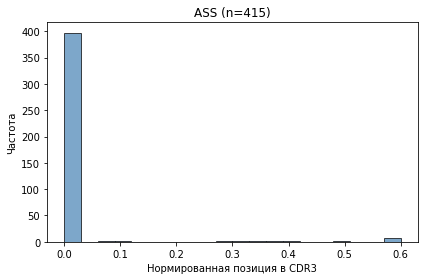

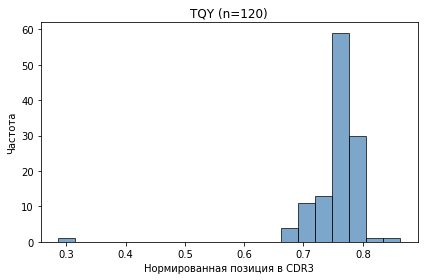

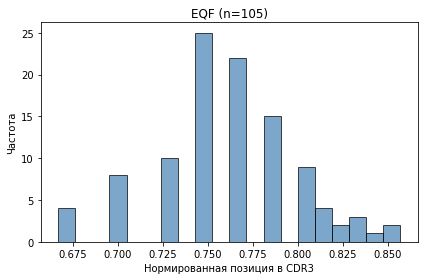

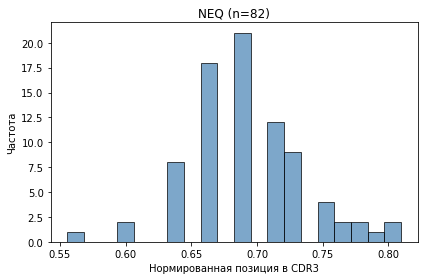

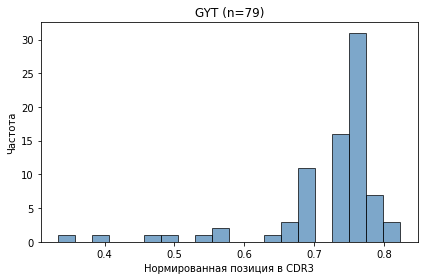

In [20]:
top5_kmers = summary.nlargest(5, 'n_hits')['kmer'].values
for kmer in top5_kmers:
    sub = df_cdr3[df_cdr3['kmer'] == kmer]
    if sub.empty:
        continue
    plt.figure(figsize=(6,4))
    plt.hist(sub['norm_position'], bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel('Нормированная позиция в CDR3')
    plt.ylabel('Частота')
    plt.title(f'{kmer} (n={len(sub)})')
    plt.tight_layout()
    plt.savefig(f"cdr3/cdr3_position_{kmer}.png", dpi=150)
    plt.show()
    plt.close()

анализ по локусам

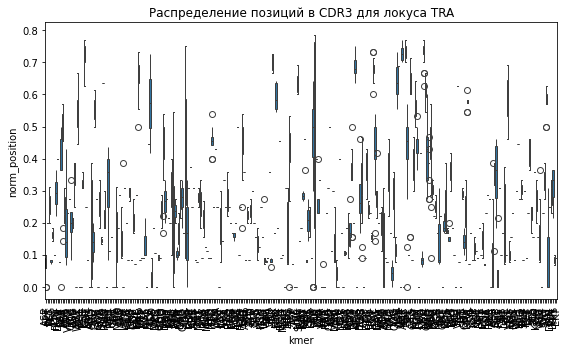

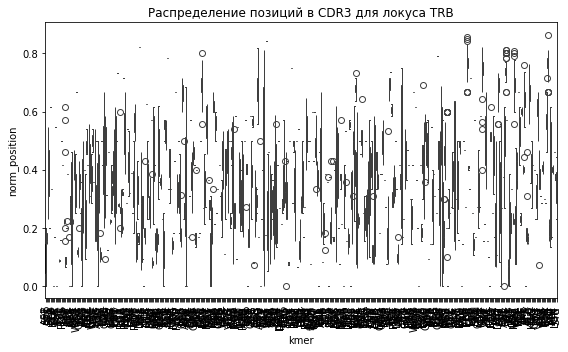

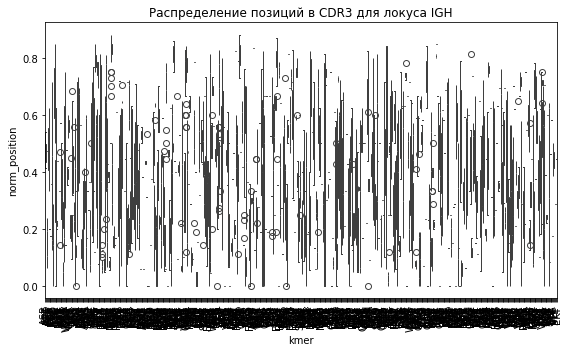

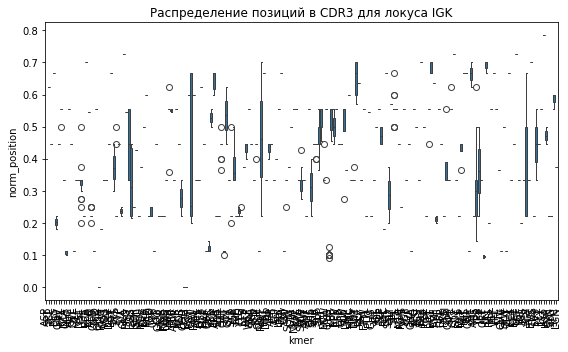

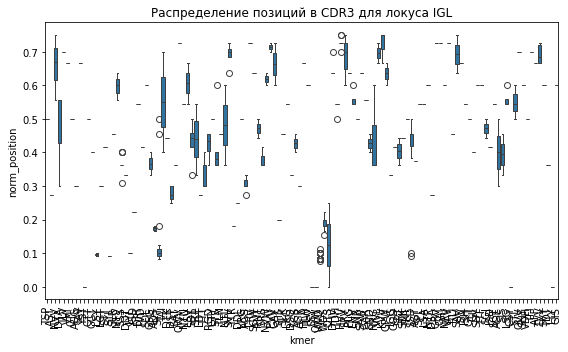

In [21]:
for locus in df_cdr3['locus'].unique():
    sub = df_cdr3[df_cdr3['locus'] == locus]
    if sub.empty:
        continue
    plt.figure(figsize=(8,5))
    sns.boxplot(data=sub, x='kmer', y='norm_position')
    plt.xticks(rotation=90)
    plt.title(f'Распределение позиций в CDR3 для локуса {locus}')
    plt.tight_layout()
    plt.savefig(f"cdr3/cdr3_positions_{locus}.png", dpi=150)
    plt.show()
    plt.close()

Определение принадлежности к V/D/J сегментам

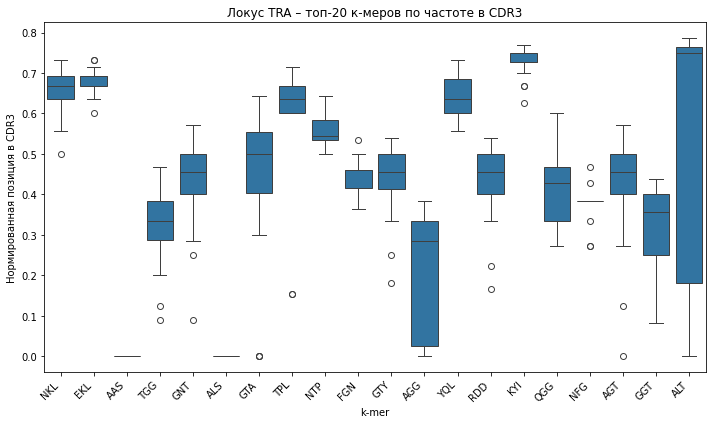

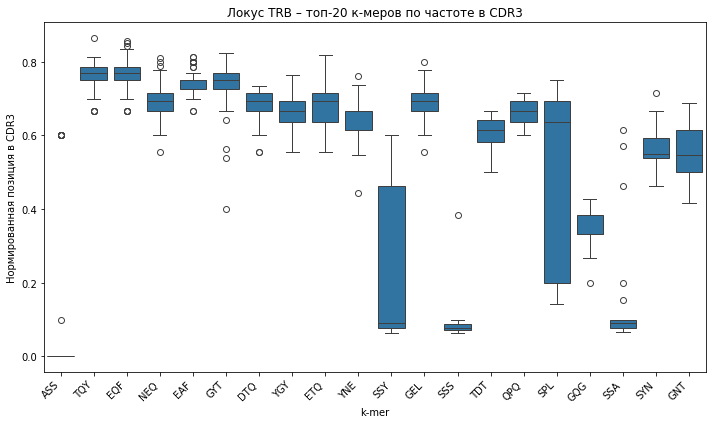

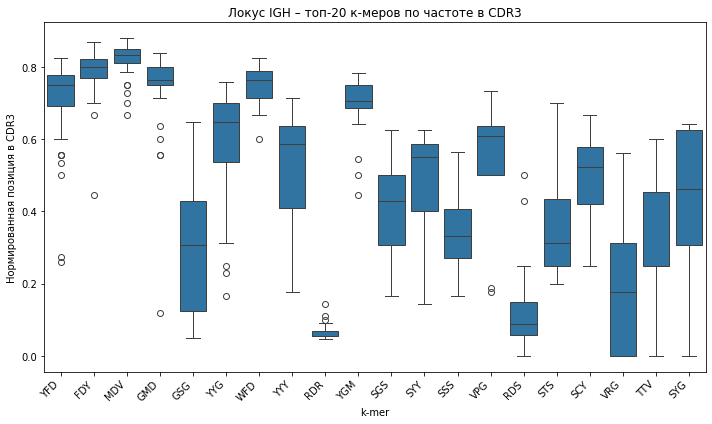

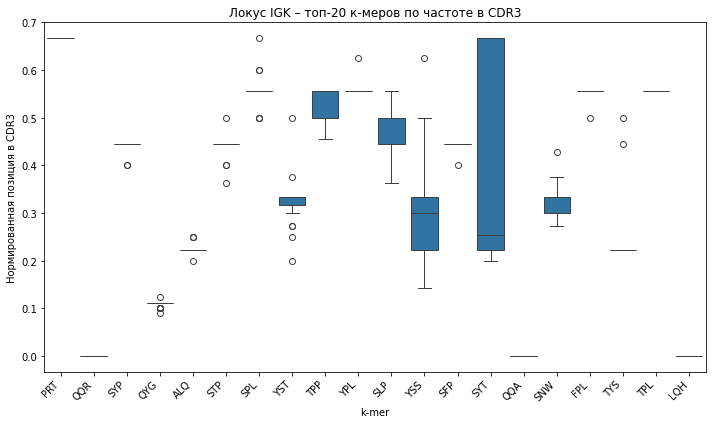

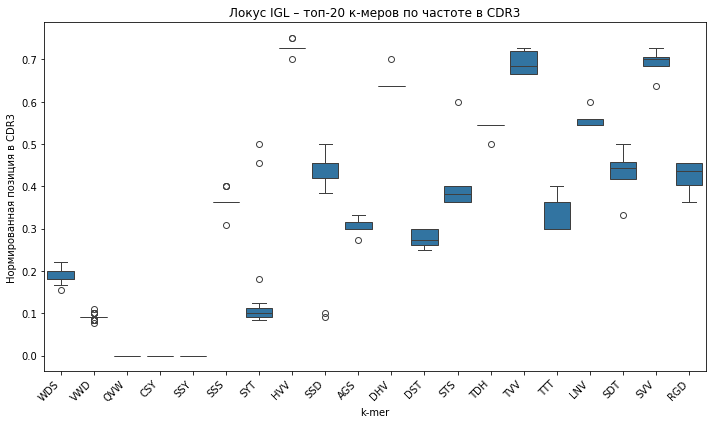

In [22]:
for locus in df_cdr3['locus'].unique():
    sub = df_cdr3[df_cdr3['locus'] == locus]
    if sub.empty:
        continue
    # Берём топ-20 к-меров по числу вхождений
    top20 = sub['kmer'].value_counts().head(20).index
    sub_top = sub[sub['kmer'].isin(top20)]
    if sub_top.empty:
        continue
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=sub_top, x='kmer', y='norm_position', order=top20)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('k-mer')
    plt.ylabel('Нормированная позиция в CDR3')
    plt.title(f'Локус {locus} – топ-20 к-меров по частоте в CDR3')
    plt.tight_layout()
    plt.savefig(f"cdr3/cdr3_positions_{locus}_top20_boxplot.png", dpi=150)
    plt.show()
    plt.close()

После фильтрации: 2811 записей
Значимых к-меров: 1162
Собрано записей: 7006


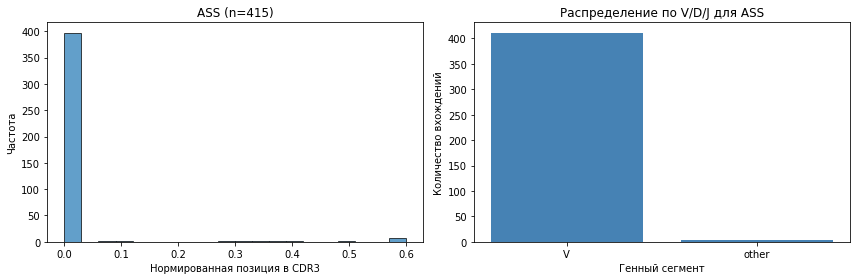

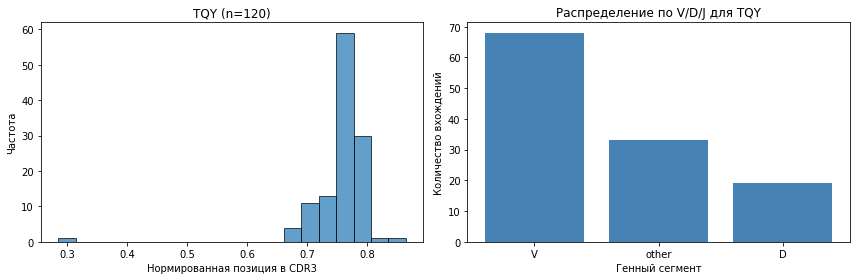

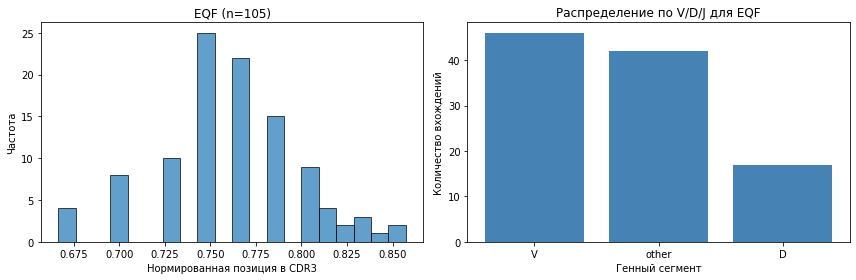

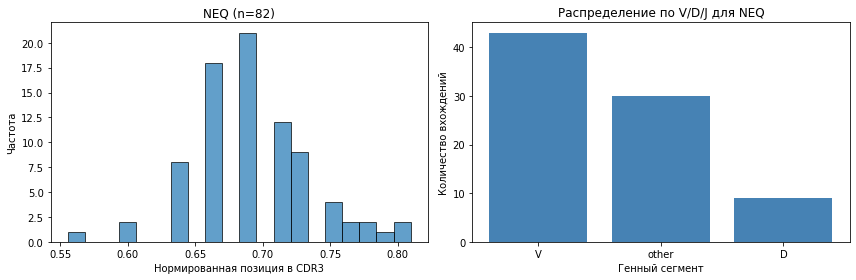

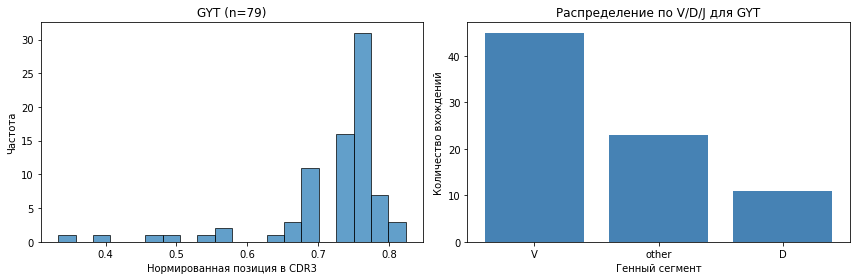

Анализ завершён. Результаты в папке cdr3/


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Создаём папку для результатов
os.makedirs("cdr3", exist_ok=True)

# ============================================================
# 1. Фильтрация исходных данных (AD, productive=T, pgen_log > -40)
# ============================================================
# Предполагается, что df_original уже загружен
# df_original = pd.read_csv("your_original_data.csv")
df_ad = df_original[
    (df_original['condition'] == 'AD') &
    (df_original['productive'] == 'T') &
    (df_original['pgen_log'] > -40)
].copy()
print(f"После фильтрации: {len(df_ad)} записей")

# ============================================================
# 2. Загрузка значимых к-меров из теста Фишера (p < 0.05)
# ============================================================
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled.csv")
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]
sig_kmers = df_fisher[df_fisher['p_value'] < 0.05]['kmer'].unique()
print(f"Значимых к-меров: {len(sig_kmers)}")

# ============================================================
# 3. Функция для определения генного сегмента (V/D/J) по координатам
# ============================================================
def get_gene_segment(row, kmer_start_in_cdr3, kmer_len=3):
    """
    Определяет, в какой генный сегмент (V/D/J) попадает k-мер.
    Использует колонки: v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end,
    j_sequence_start, j_sequence_end, cdr3_start (начало CDR3 в sequence_aa).
    """
    # Если нет необходимых колонок или они содержат NaN, возвращаем 'unknown'
    if not all(col in row.index for col in ['v_sequence_start', 'v_sequence_end', 
                                            'j_sequence_start', 'j_sequence_end', 'cdr3_start']):
        return 'unknown'
    if pd.isna(row['v_sequence_start']) or pd.isna(row['cdr3_start']):
        return 'unknown'
    
    # Абсолютная позиция начала k-мера в sequence_aa
    abs_start = row['cdr3_start'] + kmer_start_in_cdr3
    abs_end = abs_start + kmer_len - 1
    
    # Проверка V
    if row['v_sequence_start'] <= abs_start <= row['v_sequence_end'] or \
       row['v_sequence_start'] <= abs_end <= row['v_sequence_end']:
        return 'V'
    # Проверка D (если есть)
    if not pd.isna(row.get('d_sequence_start', np.nan)) and not pd.isna(row.get('d_sequence_end', np.nan)):
        if row['d_sequence_start'] <= abs_start <= row['d_sequence_end'] or \
           row['d_sequence_start'] <= abs_end <= row['d_sequence_end']:
            return 'D'
    # Проверка J
    if row['j_sequence_start'] <= abs_start <= row['j_sequence_end'] or \
       row['j_sequence_start'] <= abs_end <= row['j_sequence_end']:
        return 'J'
    return 'other'

# ============================================================
# 4. Сбор данных о позициях к-меров в CDR3 и генных сегментах
# ============================================================
records = []
kmer_len = 3  # трипептиды

for kmer in sig_kmers:
    # Ищем строки, где cdr3_aa содержит kmer
    mask = df_ad['cdr3_aa'].str.contains(kmer, na=False)
    if not mask.any():
        continue
    for idx, row in df_ad[mask].iterrows():
        cdr3 = row['cdr3_aa']
        if not isinstance(cdr3, str) or len(cdr3) < kmer_len:
            continue
        start = cdr3.find(kmer)
        if start == -1:
            continue
        cdr3_len = len(cdr3)
        norm_pos = start / cdr3_len  # нормализованная позиция (0 = начало, 1 = конец)
        # Определяем генный сегмент
        segment = get_gene_segment(row, start, kmer_len)
        records.append({
            'kmer': kmer,
            'sample_id': row['sample_id'],
            'locus': row['locus'],
            'cdr3_seq': cdr3,
            'cdr3_len': cdr3_len,
            'start_index': start,
            'norm_position': norm_pos,
            'gene_segment': segment
        })

df_cdr3 = pd.DataFrame(records)
print(f"Собрано записей: {len(df_cdr3)}")
df_cdr3.to_csv("cdr3/kmer_cdr3_positions_with_segments.csv", index=False)

# ============================================================
# 5. Сводная статистика по к-мерам
# ============================================================
summary = df_cdr3.groupby('kmer').agg(
    n_hits=('kmer', 'count'),
    mean_norm_pos=('norm_position', 'mean'),
    std_norm_pos=('norm_position', 'std'),
    most_common_segment=('gene_segment', lambda x: x.mode()[0] if len(x) > 0 else 'none')
).reset_index()
summary.to_csv("cdr3/kmer_cdr3_summary_with_segments.csv", index=False)

# ============================================================
# 6. Визуализация для топ-5 к-меров по частоте в CDR3
# ============================================================
top5_kmers = summary.nlargest(5, 'n_hits')['kmer'].values
for kmer in top5_kmers:
    sub = df_cdr3[df_cdr3['kmer'] == kmer]
    if sub.empty:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Гистограмма нормированных позиций
    axes[0].hist(sub['norm_position'], bins=20, alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Нормированная позиция в CDR3')
    axes[0].set_ylabel('Частота')
    axes[0].set_title(f'{kmer} (n={len(sub)})')
    # Распределение по генным сегментам
    seg_counts = sub['gene_segment'].value_counts()
    axes[1].bar(seg_counts.index, seg_counts.values, color='steelblue')
    axes[1].set_xlabel('Генный сегмент')
    axes[1].set_ylabel('Количество вхождений')
    axes[1].set_title(f'Распределение по V/D/J для {kmer}')
    plt.tight_layout()
    plt.savefig(f"cdr3/cdr3_analysis_{kmer}.png", dpi=150)
    plt.show()
    plt.close()

print("Анализ завершён. Результаты в папке cdr3/")

In [27]:
records[0:3]

[{'kmer': 'ASP',
  'sample_id': 'GSM3427908',
  'locus': 'TRA',
  'cdr3_seq': 'AASPMDSSYKLI',
  'cdr3_len': 12,
  'start_index': 1,
  'norm_position': 0.08333333333333333,
  'gene_segment': 'V'},
 {'kmer': 'ASP',
  'sample_id': 'GSM3427908',
  'locus': 'TRA',
  'cdr3_seq': 'ASPSGNTPLV',
  'cdr3_len': 10,
  'start_index': 0,
  'norm_position': 0.0,
  'gene_segment': 'V'},
 {'kmer': 'ASP',
  'sample_id': 'GSM3427876',
  'locus': 'TRA',
  'cdr3_seq': 'GASPSGTYKYI',
  'cdr3_len': 11,
  'start_index': 1,
  'norm_position': 0.09090909090909091,
  'gene_segment': 'V'}]


    Нормировка позиции в CDR3
    Формула: norm_position = start_index / len(cdr3_aa)

        start_index – индекс первого символа k-мера в строке CDR3 (начинается с 0).

        len(cdr3_aa) – общая длина CDR3.

        Результат от 0 (начало) до 1 (конец). Это позволяет сравнивать позиции между разными CDR3 разной длины.

    Определение генного сегмента (V/D/J)
    Функция get_gene_segment использует координаты начала/конца V, D, J сегментов в sequence_aa, а также координату начала CDR3 (cdr3_start), чтобы вычислить абсолютную позицию k-мера. Если необходимые колонки отсутствуют, все значения будут 'unknown'. Вы можете адаптировать названия колонок под свой датафрейм.

    Результаты

        cdr3/kmer_cdr3_positions_with_segments.csv – все вхождения к-меров в CDR3 с указанием позиции и сегмента.

        cdr3/kmer_cdr3_summary_with_segments.csv – сводка по каждому к-меру: число вхождений, средняя позиция, стандартное отклонение, самый частый сегмент.

        Графики для топ-5 к-меров сохраняются в cdr3/cdr3_analysis_<kmer>.png.

    Визуализация
    Для каждого из топ-5 к-меров строятся две диаграммы:

        Гистограмма нормированных позиций – показывает, есть ли смещение к началу (0) или концу (1) CDR3.

        Столбчатая диаграмма распределения по сегментам (V, D, J, other, unknown).

Как интерпретировать результаты

    Равномерное распределение нормированной позиции – к-мер равновероятно встречается в любой части CDR3.

    Пик около 0 – к-мер тяготеет к началу CDR3 (ближе к V-сегменту).

    Пик около 1 – к-мер тяготеет к концу CDR3 (ближе к J-сегменту).

    Если большинство вхождений попадает в сегмент 'V' или 'J' (при наличии координат), это указывает на происхождение к-мера из соответствующего гена.

После фильтрации: 2811 записей
Значимых к-меров: 1162
Обработано 0 из 1162
Обработано 100 из 1162
Обработано 200 из 1162
Обработано 300 из 1162
Обработано 400 из 1162
Обработано 500 из 1162
Обработано 600 из 1162
Обработано 700 из 1162
Обработано 800 из 1162
Обработано 900 из 1162
Обработано 1000 из 1162
Обработано 1100 из 1162
Собрано записей: 7006

Топ-20 к-меров по частоте в CDR3:
ASS: 415
TQY: 120
EQF: 105
NEQ: 82
GYT: 79
EAF: 77
SSY: 77
SSS: 74
YFD: 64
DTQ: 63
NKL: 62
GSG: 57
FDY: 55
WDS: 53
EKL: 53
MDV: 53
SPL: 51
TGG: 51
YGY: 51
ETQ: 50


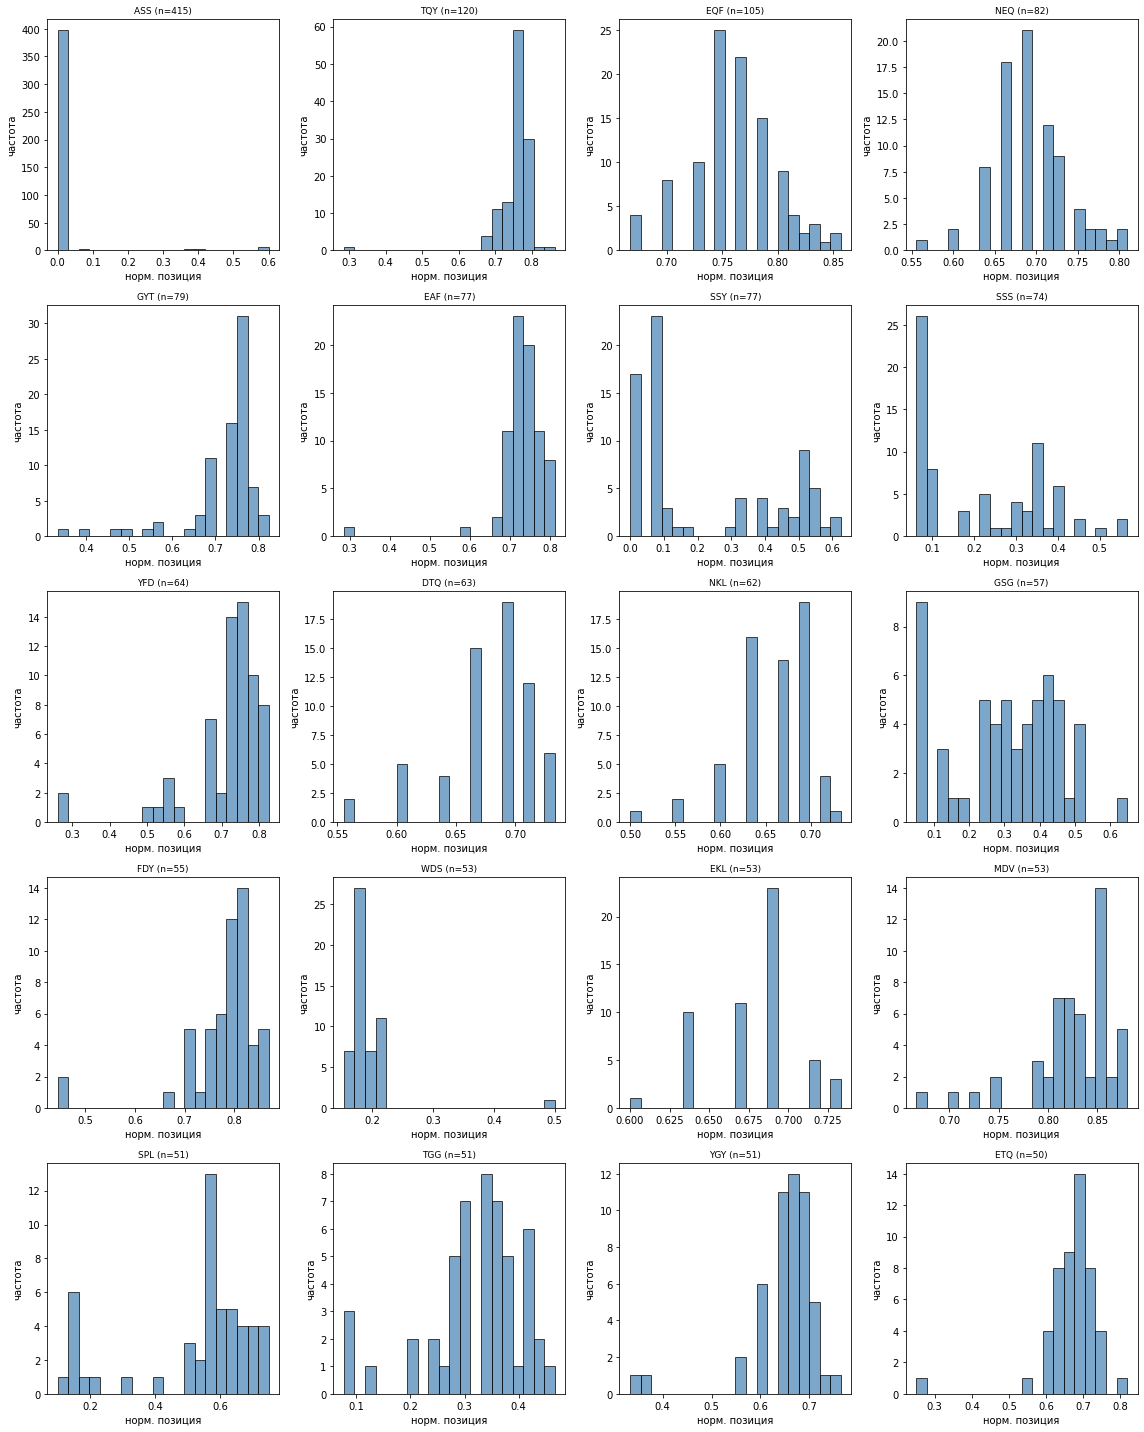

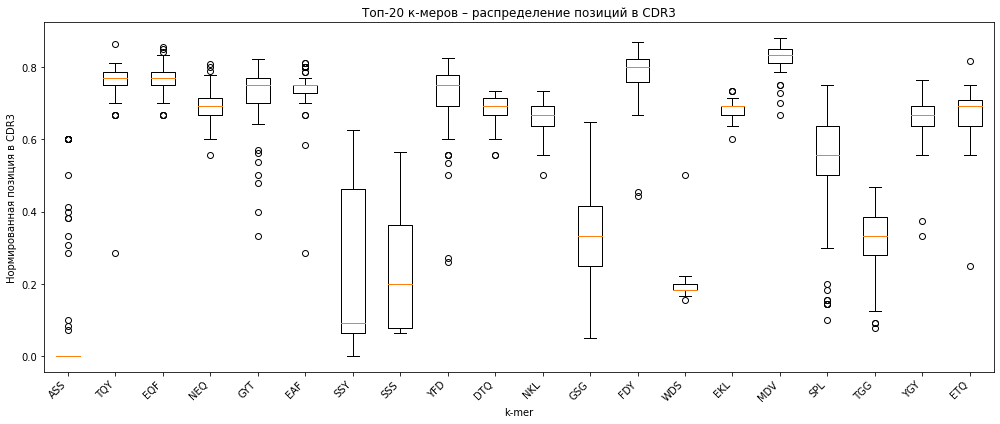

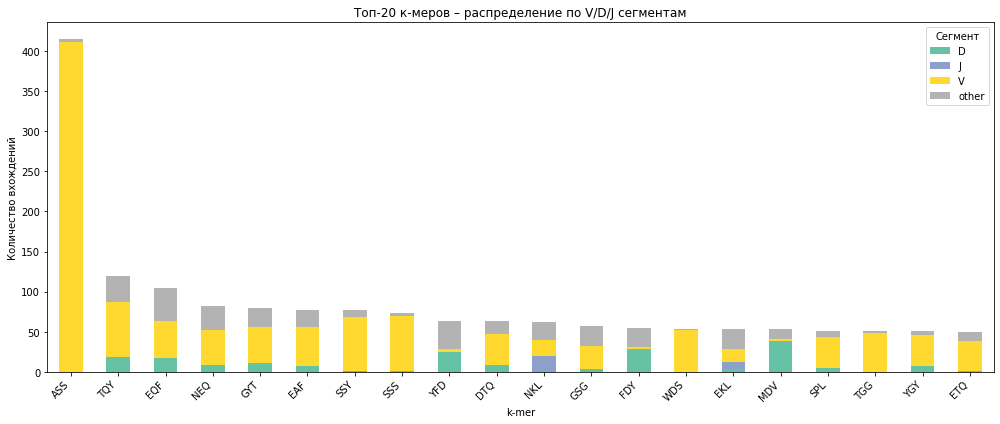

Анализ завершён. Результаты в папке cdr3/


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Создаём папку для результатов
os.makedirs("cdr3", exist_ok=True)

# ============================================================
# 1. Загрузка и фильтрация данных
# ============================================================
# Предполагается, что df_original уже загружен (например, из CSV)
# df_original = pd.read_csv("data_filtered.csv")
df_ad = df_original[
    (df_original['condition'] == 'AD') &
    (df_original['productive'] == 'T') &
    (df_original['pgen_log'] > -40)
].copy()
print(f"После фильтрации: {len(df_ad)} записей")

# ============================================================
# 2. Загрузка значимых к-меров (p < 0.05) из теста Фишера
# ============================================================
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled.csv")
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]
sig_kmers = df_fisher[df_fisher['p_value'] < 0.05]['kmer'].unique()
print(f"Значимых к-меров: {len(sig_kmers)}")

# ============================================================
# 3. Функция определения сегмента (V/D/J) по координатам
# ============================================================
def get_gene_segment(row, kmer_start_in_cdr3, kmer_len=3):
    """
    row - pandas Series (одна строка df_ad)
    kmer_start_in_cdr3 - позиция начала k-мера в cdr3_aa (0-based)
    Возвращает: 'V', 'D', 'J', 'other' или 'unknown'
    """
    # Проверяем наличие необходимых колонок
    required = ['cdr3_start', 'v_sequence_start', 'v_sequence_end', 
                'j_sequence_start', 'j_sequence_end']
    if not all(col in row for col in required):
        return 'unknown'
    # Проверяем, что значения не NaN
    if any(pd.isna(row[col]) for col in required):
        return 'unknown'
    
    # Абсолютная позиция начала k-мера в sequence_aa
    abs_start = row['cdr3_start'] + kmer_start_in_cdr3
    abs_end = abs_start + kmer_len - 1
    
    # V
    if row['v_sequence_start'] <= abs_start <= row['v_sequence_end'] or \
       row['v_sequence_start'] <= abs_end <= row['v_sequence_end']:
        return 'V'
    # J
    if row['j_sequence_start'] <= abs_start <= row['j_sequence_end'] or \
       row['j_sequence_start'] <= abs_end <= row['j_sequence_end']:
        return 'J'
    # D (если есть)
    if 'd_sequence_start' in row and 'd_sequence_end' in row:
        if not pd.isna(row['d_sequence_start']) and not pd.isna(row['d_sequence_end']):
            if row['d_sequence_start'] <= abs_start <= row['d_sequence_end'] or \
               row['d_sequence_start'] <= abs_end <= row['d_sequence_end']:
                return 'D'
    return 'other'

# ============================================================
# 4. Сбор данных о позициях и сегментах для значимых к-меров
# ============================================================
records = []
kmer_len = 3
total = len(sig_kmers)
for i, kmer in enumerate(sig_kmers):
    if i % 100 == 0:
        print(f"Обработано {i} из {total}")
    # Ищем строки, где cdr3_aa содержит kmer
    mask = df_ad['cdr3_aa'].str.contains(kmer, na=False)
    if not mask.any():
        continue
    for idx, row in df_ad[mask].iterrows():
        cdr3 = row['cdr3_aa']
        if not isinstance(cdr3, str) or len(cdr3) < kmer_len:
            continue
        start = cdr3.find(kmer)
        if start == -1:
            continue
        cdr3_len = len(cdr3)
        norm_pos = start / cdr3_len
        segment = get_gene_segment(row, start, kmer_len)
        records.append({
            'kmer': kmer,
            'sample_id': row['sample_id'],
            'locus': row['locus'],
            'cdr3_seq': cdr3,
            'cdr3_len': cdr3_len,
            'start_index': start,
            'norm_position': norm_pos,
            'gene_segment': segment
        })

df_cdr3 = pd.DataFrame(records)
print(f"Собрано записей: {len(df_cdr3)}")
df_cdr3.to_csv("cdr3/kmer_cdr3_positions_with_segments.csv", index=False)

# ============================================================
# 5. Сводная статистика по к-мерам
# ============================================================
summary = df_cdr3.groupby('kmer').agg(
    n_hits=('kmer', 'count'),
    mean_norm_pos=('norm_position', 'mean'),
    std_norm_pos=('norm_position', 'std'),
    most_common_segment=('gene_segment', lambda x: x.mode()[0] if len(x) > 0 else 'none')
).reset_index()
summary.to_csv("cdr3/kmer_cdr3_summary_with_segments.csv", index=False)

# ============================================================
# 6. Визуализация для топ-20 к-меров по частоте в CDR3
# ============================================================
top20_kmers = df_cdr3['kmer'].value_counts().head(20).index
if len(top20_kmers) == 0:
    print("Нет данных для визуализации.")
    exit()

print("\nТоп-20 к-меров по частоте в CDR3:")
for kmer in top20_kmers:
    print(f"{kmer}: {df_cdr3[df_cdr3['kmer']==kmer].shape[0]}")

# 6.1 Гистограммы нормированных позиций
n_cols = 4
n_rows = (len(top20_kmers) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()
for i, kmer in enumerate(top20_kmers):
    ax = axes[i]
    sub = df_cdr3[df_cdr3['kmer'] == kmer]['norm_position'].dropna()
    if len(sub) == 0:
        ax.text(0.5, 0.5, 'нет данных', ha='center', va='center')
        ax.set_title(kmer)
        continue
    ax.hist(sub, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(f'{kmer} (n={len(sub)})', fontsize=9)
    ax.set_xlabel('норм. позиция')
    ax.set_ylabel('частота')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("cdr3/top20_cdr3_histograms.png", dpi=150)
plt.show()
plt.close()

# 6.2 Boxplot
plt.figure(figsize=(14, 6))
data_for_box = []
valid_labels = []
for kmer in top20_kmers:
    vals = df_cdr3[df_cdr3['kmer'] == kmer]['norm_position'].dropna().values
    if len(vals) > 0:
        data_for_box.append(vals)
        valid_labels.append(kmer)
if data_for_box:
    plt.boxplot(data_for_box, labels=valid_labels)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('k-mer')
    plt.ylabel('Нормированная позиция в CDR3')
    plt.title('Топ-20 к-меров – распределение позиций в CDR3')
    plt.tight_layout()
    plt.savefig("cdr3/top20_cdr3_boxplot.png", dpi=150)
    plt.show()
else:
    print("Нет данных для boxplot")
plt.close()

# 6.3 Stacked bar chart: распределение по сегментам для топ-20
segment_counts = df_cdr3[df_cdr3['kmer'].isin(top20_kmers)].groupby(['kmer', 'gene_segment']).size().unstack(fill_value=0)
segment_counts = segment_counts.reindex(top20_kmers, fill_value=0)
if not segment_counts.empty:
    segment_counts.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Set2')
    plt.xlabel('k-mer')
    plt.ylabel('Количество вхождений')
    plt.title('Топ-20 к-меров – распределение по V/D/J сегментам')
    plt.legend(title='Сегмент')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("cdr3/top20_cdr3_segments.png", dpi=150)
    plt.show()
else:
    print("Нет данных для stacked bar chart")
plt.close()

print("Анализ завершён. Результаты в папке cdr3/")

После фильтрации: 2811 записей
Локусы: ['IGH' 'TRA' 'TRB' 'IGK' 'IGL']
Всего значимых к-меров: 1238

Обработка локуса: IGH
  Записей в локусе: 871
  Значимых к-меров в локусе: 624
  Собрано записей в CDR3: 1319

  Распределение по генным сегментам для IGH:
gene_segment
J        489
D        393
V        221
other    216
Name: count, dtype: int64
  Топ-20 к-меров для IGH: ['YFD', 'FDY', 'MDV', 'GMD', 'GSG']...


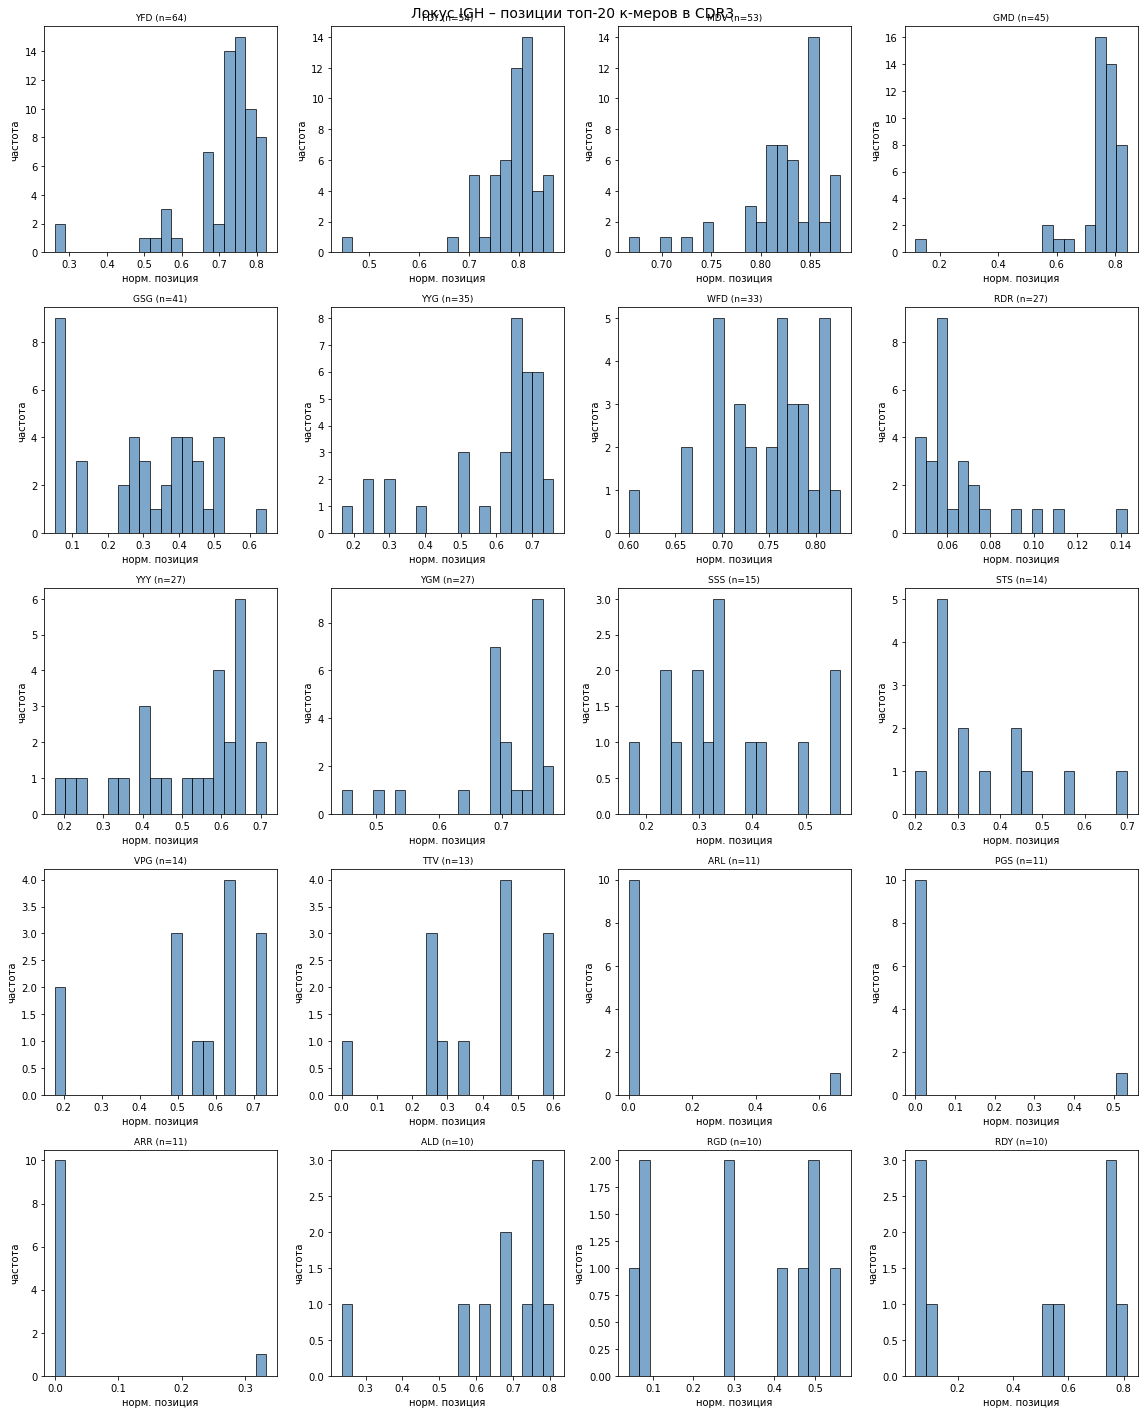

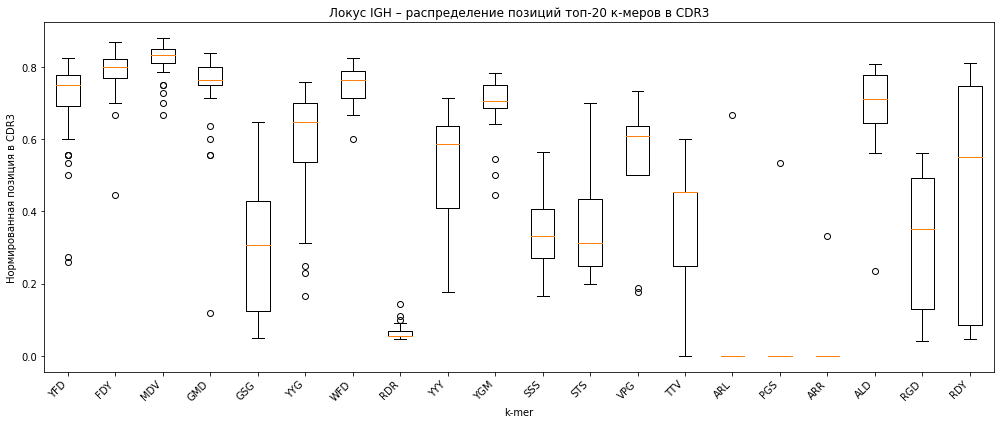

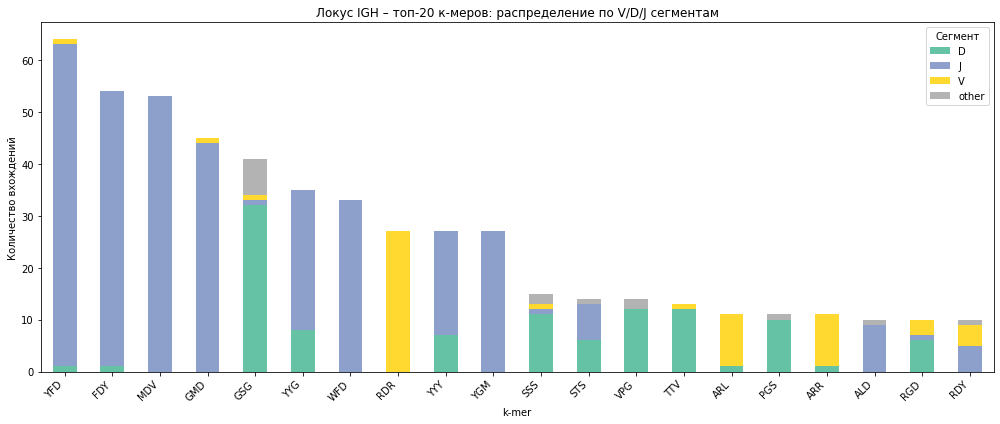


Обработка локуса: TRA
  Записей в локусе: 578
  Значимых к-меров в локусе: 143
  Собрано записей в CDR3: 240

  Распределение по генным сегментам для TRA:
gene_segment
J        199
V         39
other      2
Name: count, dtype: int64
  Топ-20 к-меров для TRA: ['GNT', 'TPL', 'FGN', 'NTP', 'YQL']...


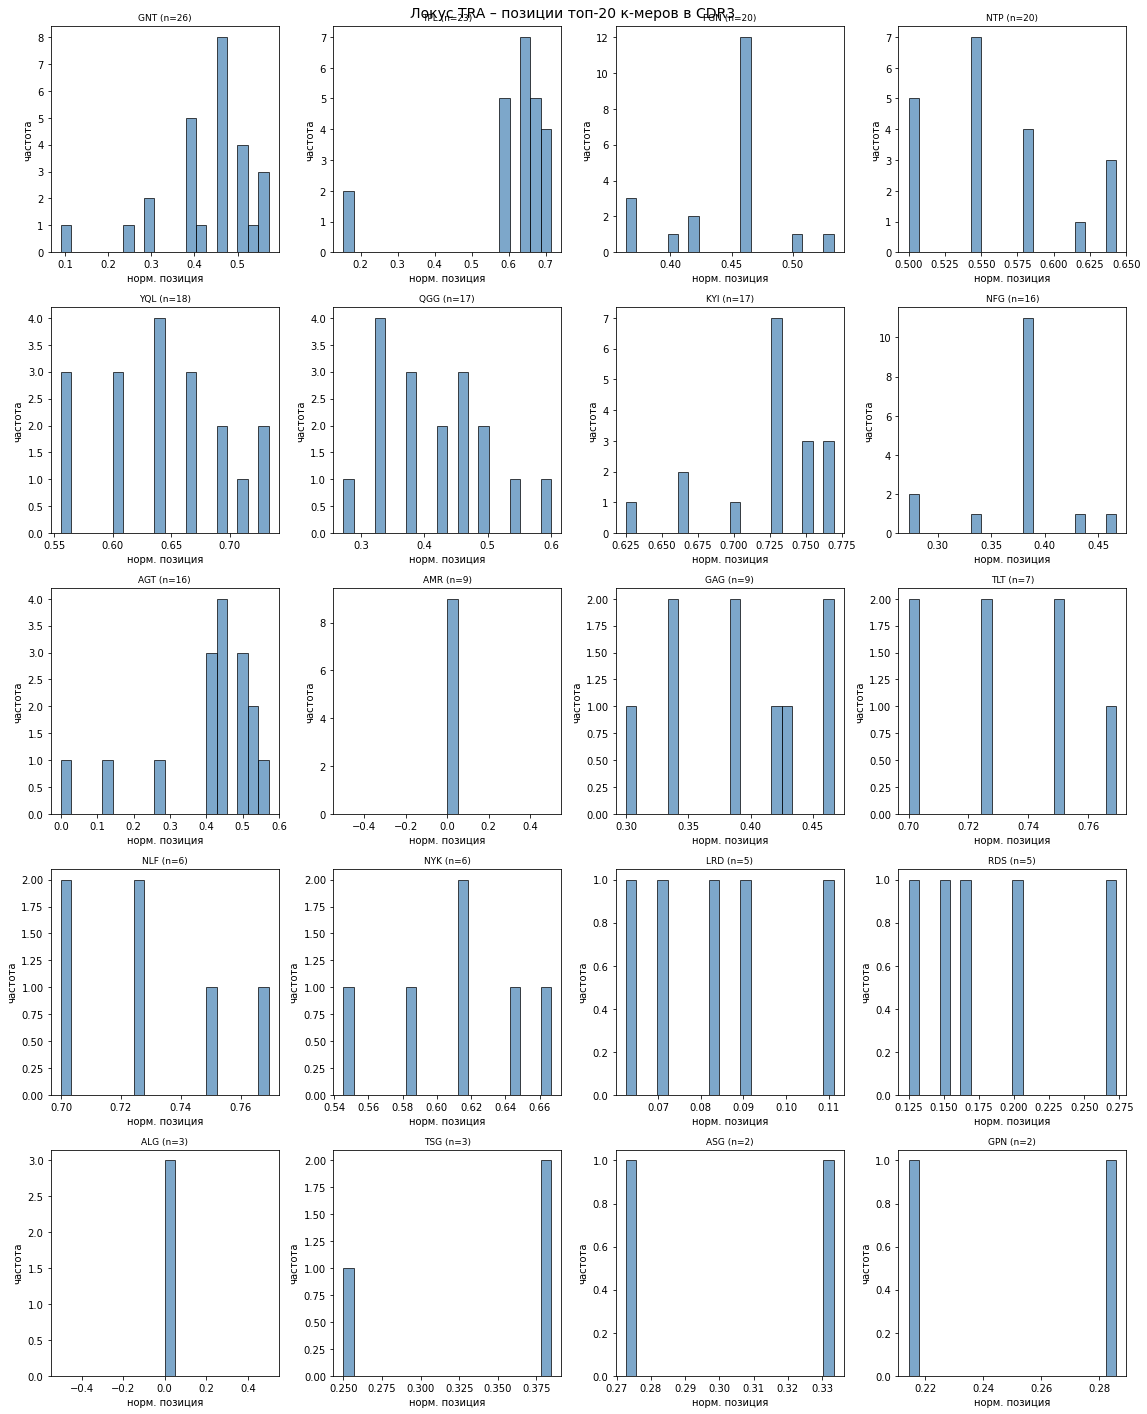

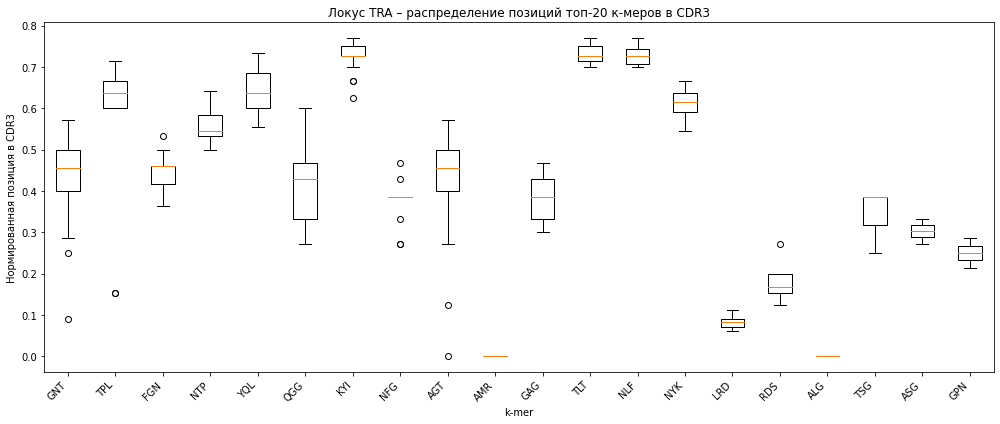

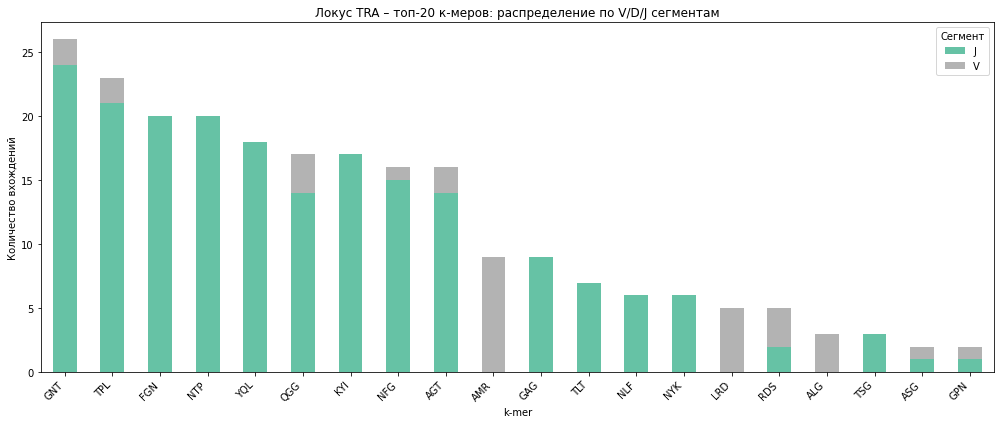


Обработка локуса: TRB
  Записей в локусе: 705
  Значимых к-меров в локусе: 361
  Собрано записей в CDR3: 1391

  Распределение по генным сегментам для TRB:
gene_segment
J        737
V        543
D         70
other     41
Name: count, dtype: int64
  Топ-20 к-меров для TRB: ['ASS', 'TQY', 'EQF', 'NEQ', 'EAF']...


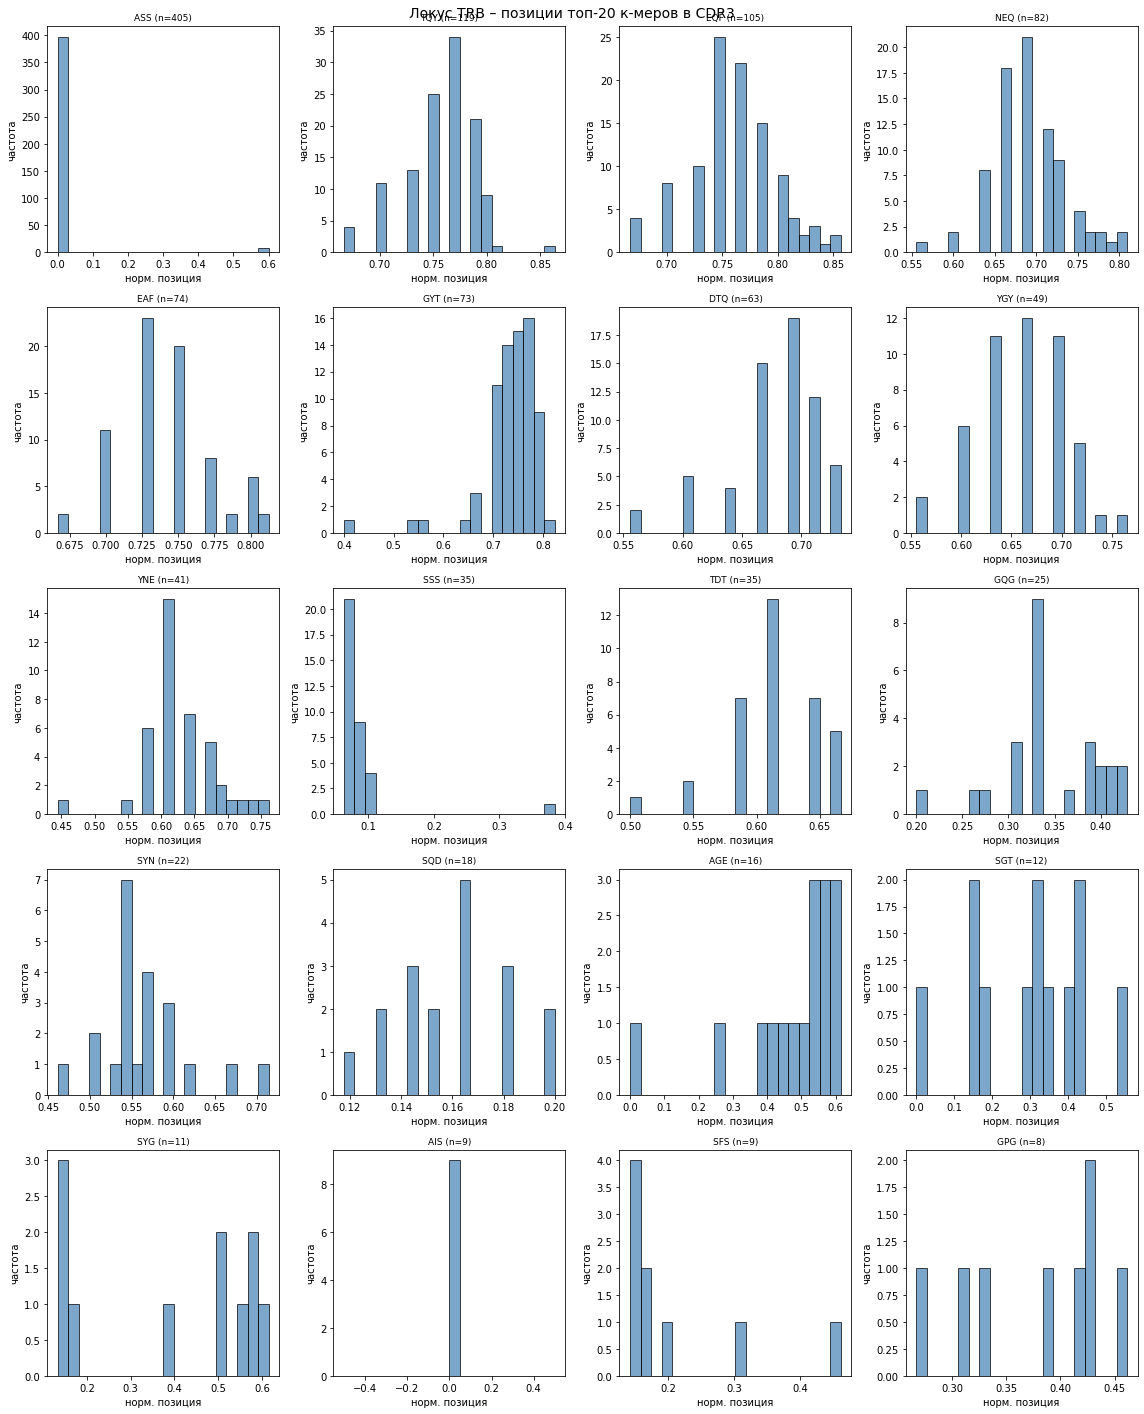

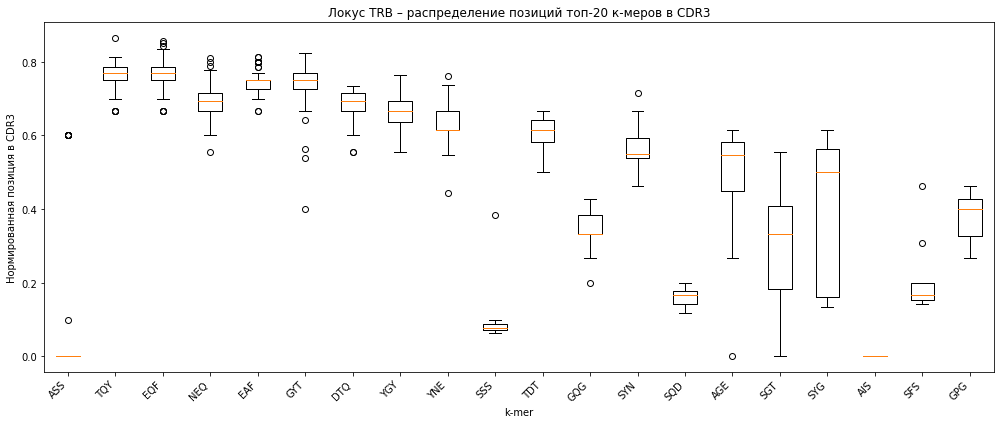

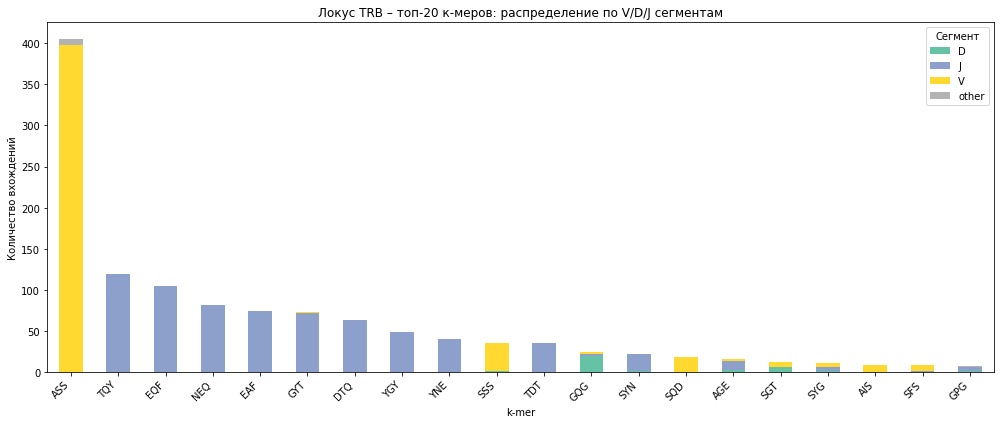


Обработка локуса: IGK
  Записей в локусе: 506
  Значимых к-меров в локусе: 69
  Собрано записей в CDR3: 148

  Распределение по генным сегментам для IGK:
gene_segment
V    140
J      8
Name: count, dtype: int64
  Топ-20 к-меров для IGK: ['SYP', 'QYG', 'TPP', 'SLP', 'DSY']...


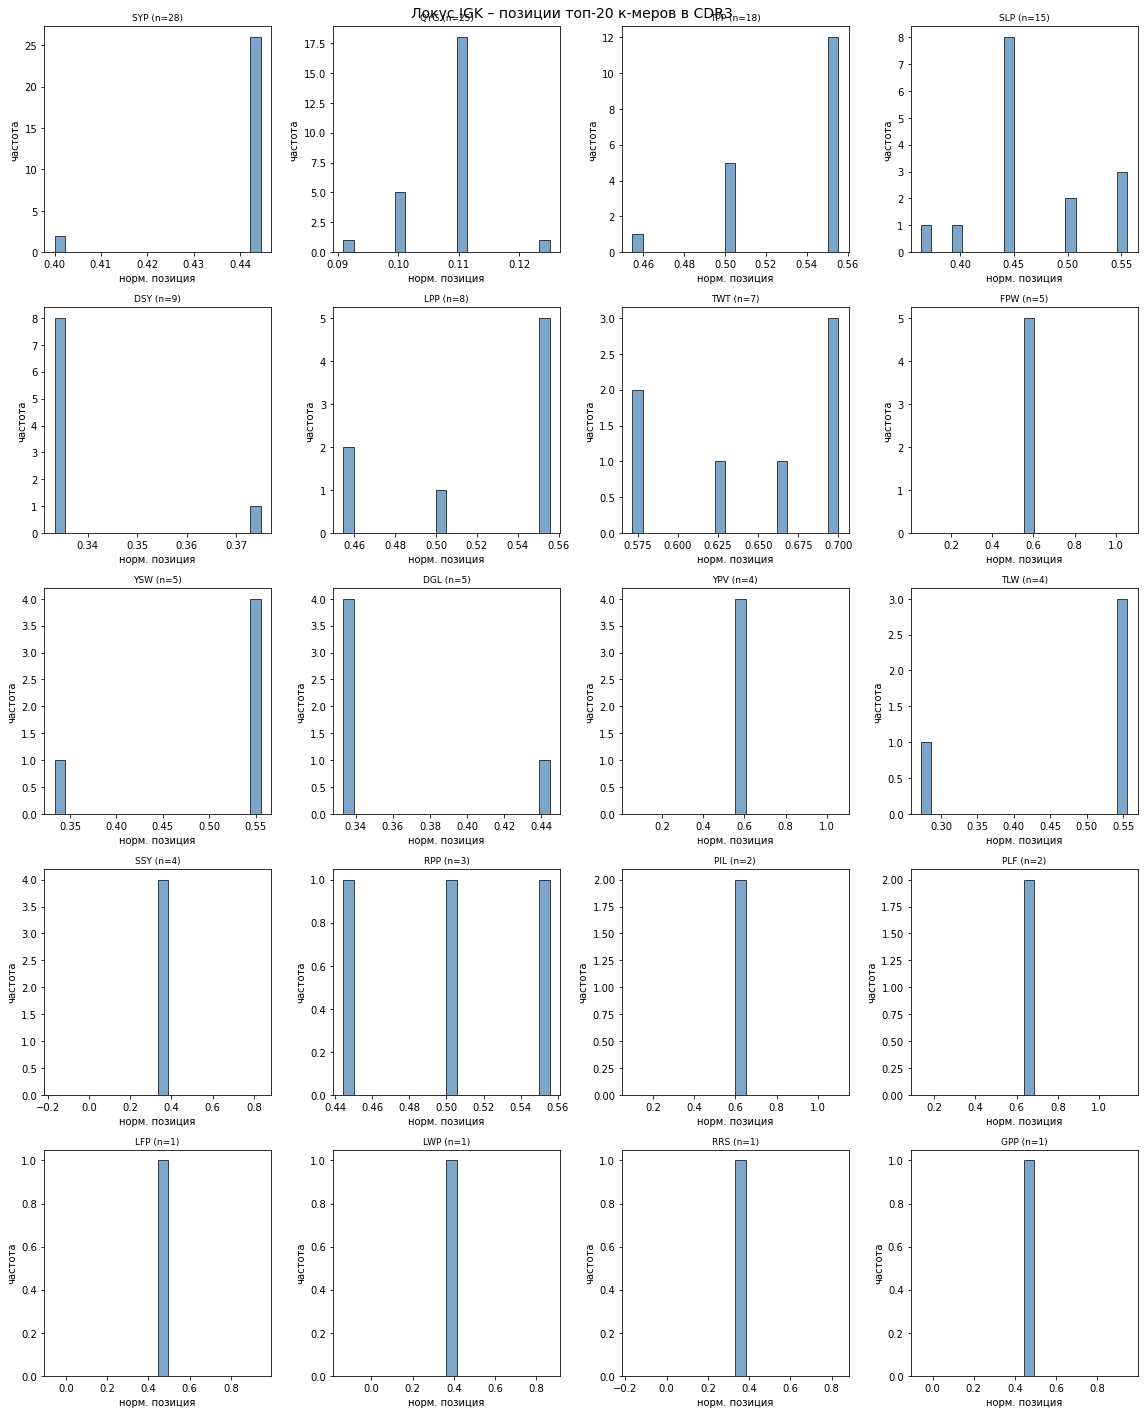

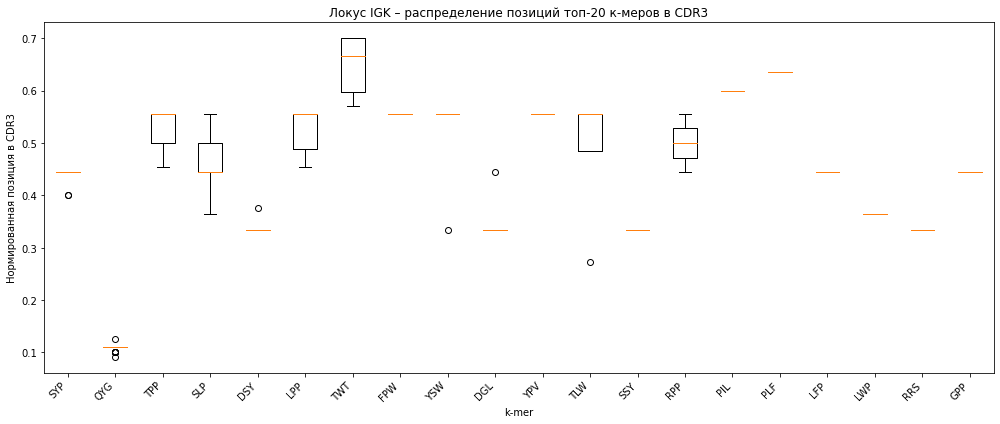

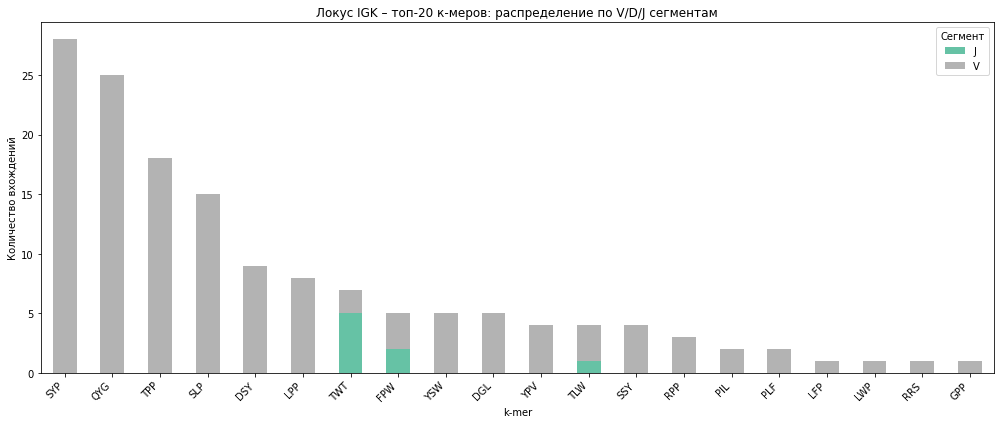


Обработка локуса: IGL
  Записей в локусе: 151
  Значимых к-меров в локусе: 41
  Собрано записей в CDR3: 205

  Распределение по генным сегментам для IGL:
gene_segment
V        199
J          5
other      1
Name: count, dtype: int64
  Топ-20 к-меров для IGL: ['WDS', 'QVW', 'VWD', 'HVV', 'DHV']...


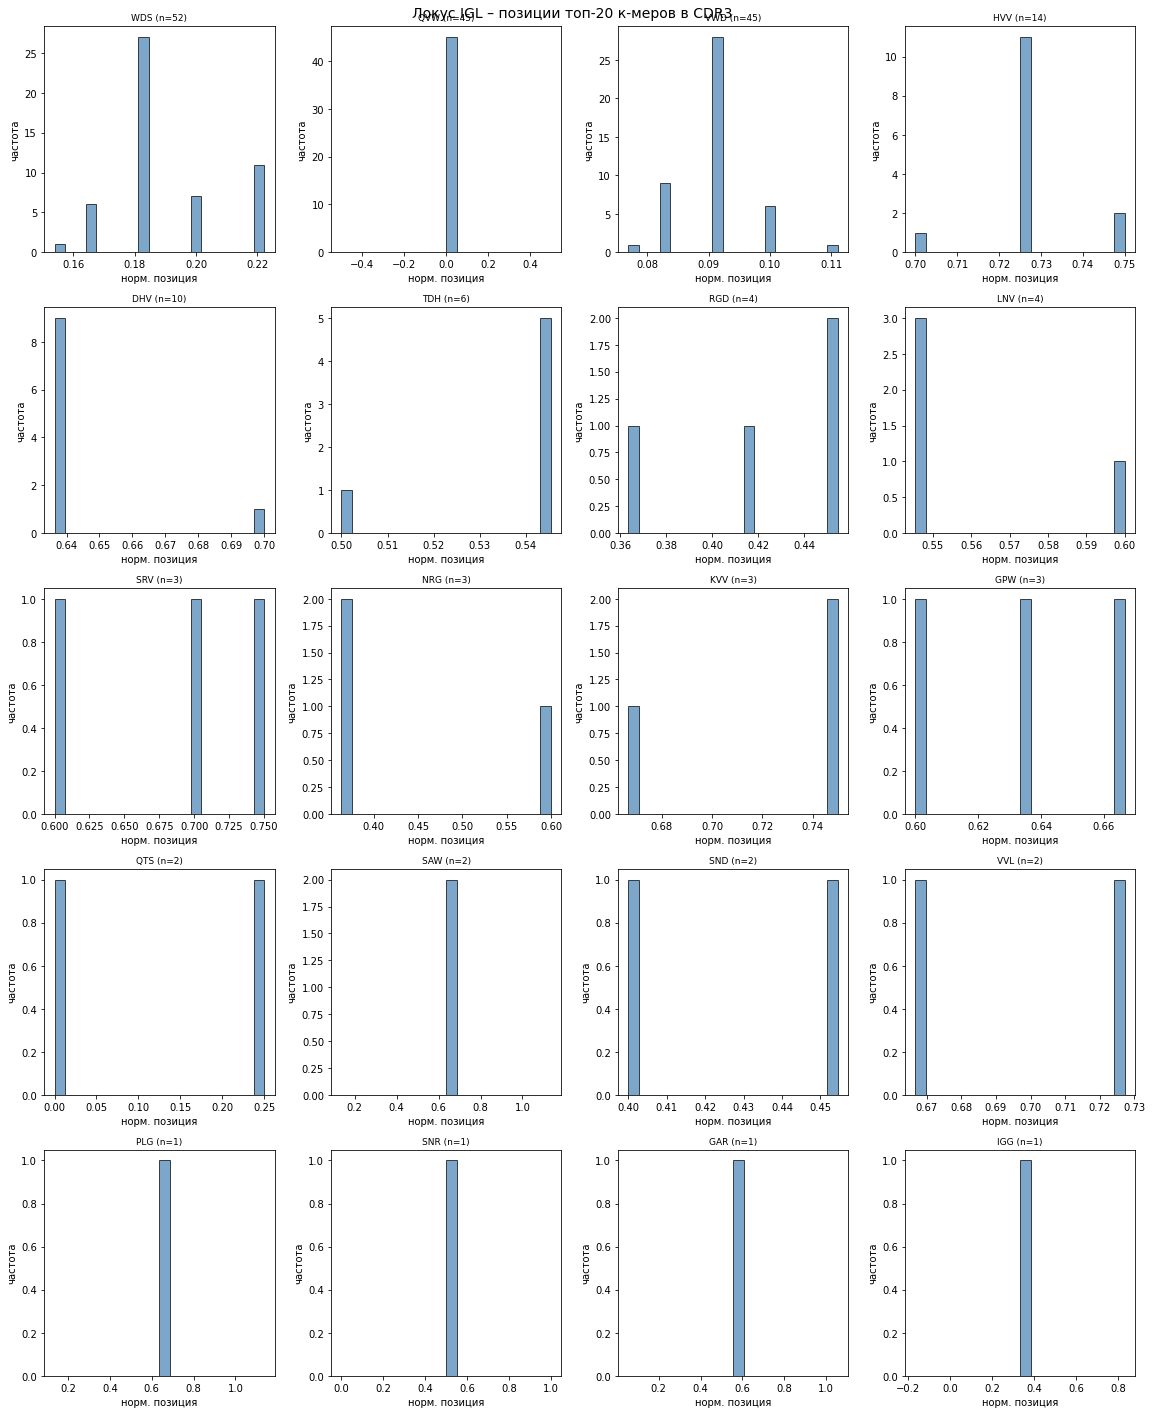

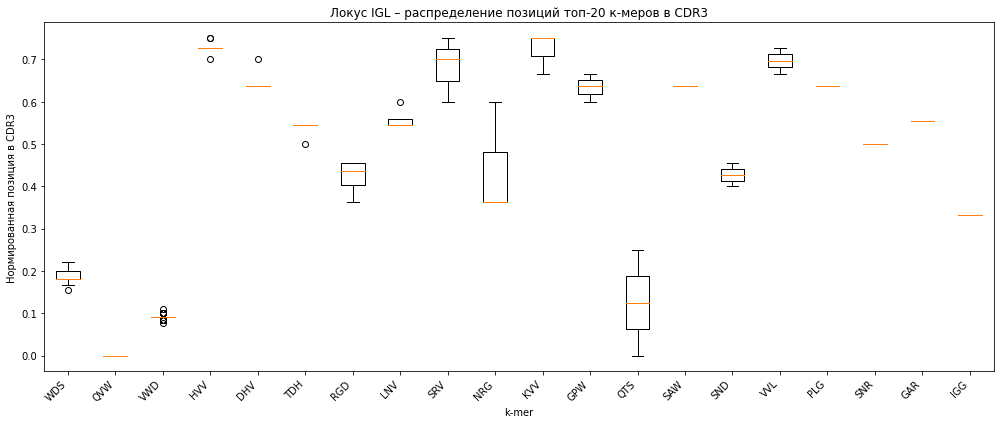

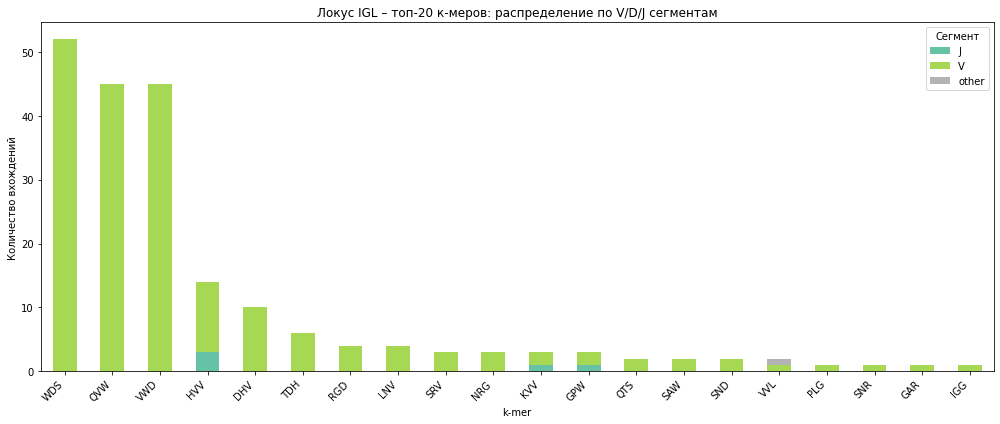


Анализ завершён. Все результаты в папке cdr3/


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Создаём папку для результатов
os.makedirs("cdr3", exist_ok=True)

# ============================================================
# 1. Загрузка и фильтрация исходных данных
# ============================================================
# Предполагается, что df_original уже загружен (например, из CSV)
# df_original = pd.read_csv("data_filtered.csv")

df_ad = df_original[
    (df_original['condition'] == 'AD') &
    (df_original['productive'] == 'T') &
    (df_original['pgen_log'] > -40)
].copy()
print(f"После фильтрации: {len(df_ad)} записей")
print(f"Локусы: {df_ad['locus'].unique()}")

# ============================================================
# 2. Загрузка значимых к-меров из теста Фишера (p < 0.05)
# ============================================================
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled.csv")
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]
df_fisher['significant'] = df_fisher['p_value'] < 0.05
print(f"Всего значимых к-меров: {df_fisher[df_fisher['significant']].shape[0]}")

# ============================================================
# 3. Функция для перевода нуклеотидных координат в аминокислотные
# ============================================================
def nucleotide_to_aa_pos(nuc_pos):
    """
    Переводит нуклеотидную позицию в аминокислотную.
    nuc_pos - нуклеотидная позиция (1-based)
    Возвращает аминокислотную позицию (1-based)
    """
    if pd.isna(nuc_pos) or nuc_pos < 0:
        return np.nan
    return (int(nuc_pos) - 1) // 3 + 1

# ============================================================
# 4. Функция определения генного сегмента (V/D/J)
# ============================================================
def get_gene_segment(row, kmer_start_in_cdr3, kmer_len=3):
    """
    row - pandas Series (одна строка df_ad)
    kmer_start_in_cdr3 - позиция начала k-мера в cdr3_aa (0-based)
    Возвращает: 'V', 'D', 'J', 'other' или 'unknown'
    """
    # Проверяем наличие необходимых колонок
    required = ['cdr3_start', 'v_sequence_start', 'v_sequence_end', 
                'j_sequence_start', 'j_sequence_end']
    
    for col in required:
        if col not in row.index:
            return 'unknown'
        if pd.isna(row[col]):
            return 'unknown'
    
    # Переводим нуклеотидные координаты в аминокислотные
    cdr3_start_aa = nucleotide_to_aa_pos(row['cdr3_start'])
    v_start_aa = nucleotide_to_aa_pos(row['v_sequence_start'])
    v_end_aa = nucleotide_to_aa_pos(row['v_sequence_end'])
    j_start_aa = nucleotide_to_aa_pos(row['j_sequence_start'])
    j_end_aa = nucleotide_to_aa_pos(row['j_sequence_end'])
    
    # Проверяем, что все координаты валидны
    if any(pd.isna(x) for x in [cdr3_start_aa, v_start_aa, v_end_aa, j_start_aa, j_end_aa]):
        return 'unknown'
    
    # Абсолютная позиция начала k-мера в sequence_aa (1-based)
    abs_start = cdr3_start_aa + kmer_start_in_cdr3
    abs_end = abs_start + kmer_len - 1
    
    # Проверка V
    if v_start_aa <= abs_start <= v_end_aa or v_start_aa <= abs_end <= v_end_aa:
        return 'V'
    
    # Проверка J
    if j_start_aa <= abs_start <= j_end_aa or j_start_aa <= abs_end <= j_end_aa:
        return 'J'
    
    # Проверка D (если есть)
    if 'd_sequence_start' in row and 'd_sequence_end' in row:
        if not pd.isna(row['d_sequence_start']) and not pd.isna(row['d_sequence_end']):
            d_start_aa = nucleotide_to_aa_pos(row['d_sequence_start'])
            d_end_aa = nucleotide_to_aa_pos(row['d_sequence_end'])
            if not pd.isna(d_start_aa) and not pd.isna(d_end_aa):
                if d_start_aa <= abs_start <= d_end_aa or d_start_aa <= abs_end <= d_end_aa:
                    return 'D'
    
    return 'other'

# ============================================================
# 5. Функция для поиска позиции k-мера в CDR3
# ============================================================
def get_cdr3_position_info(kmer, cdr3_seq):
    if pd.isna(cdr3_seq) or not isinstance(cdr3_seq, str):
        return None
    pos = cdr3_seq.find(kmer)
    if pos == -1:
        return None
    cdr3_len = len(cdr3_seq)
    norm_pos = pos / cdr3_len if cdr3_len > 0 else np.nan
    return {
        'cdr3_start_index': pos,
        'cdr3_len': cdr3_len,
        'norm_position': norm_pos
    }

# ============================================================
# 6. Анализ по каждому локусу отдельно
# ============================================================
loci = df_ad['locus'].unique()

for locus in loci:
    print(f"\n{'='*60}")
    print(f"Обработка локуса: {locus}")
    print(f"{'='*60}")
    
    # 6.1 Фильтруем данные по локусу
    df_locus = df_ad[df_ad['locus'] == locus].copy()
    print(f"  Записей в локусе: {len(df_locus)}")
    
    # 6.2 Значимые к-меры для этого локуса
    sig_kmers_locus = df_fisher[(df_fisher['locus'] == locus) & (df_fisher['significant'])]['kmer'].unique()
    print(f"  Значимых к-меров в локусе: {len(sig_kmers_locus)}")
    
    if len(sig_kmers_locus) == 0:
        print(f"  Нет значимых к-меров для локуса {locus}, пропускаем.")
        continue
    
    # 6.3 Сбор данных о позициях в CDR3 и сегментах
    records = []
    kmer_len = 3
    
    for kmer in sig_kmers_locus:
        # Ищем строки, где cdr3_aa содержит kmer
        mask = df_locus['cdr3_aa'].str.contains(kmer, na=False)
        if not mask.any():
            continue
        for idx, row in df_locus[mask].iterrows():
            cdr3 = row['cdr3_aa']
            if not isinstance(cdr3, str) or len(cdr3) < kmer_len:
                continue
            start = cdr3.find(kmer)
            if start == -1:
                continue
            cdr3_len = len(cdr3)
            norm_pos = start / cdr3_len
            segment = get_gene_segment(row, start, kmer_len)
            records.append({
                'kmer': kmer,
                'sample_id': row['sample_id'],
                'cdr3_seq': cdr3,
                'cdr3_len': cdr3_len,
                'start_index': start,
                'norm_position': norm_pos,
                'gene_segment': segment
            })
    
    if len(records) == 0:
        print(f"  Нет вхождений в CDR3 для локуса {locus}")
        continue
    
    df_cdr3_locus = pd.DataFrame(records)
    print(f"  Собрано записей в CDR3: {len(df_cdr3_locus)}")
    
    # Выводим распределение по сегментам
    print(f"\n  Распределение по генным сегментам для {locus}:")
    print(df_cdr3_locus['gene_segment'].value_counts())
    
    # 6.4 Сохранение таблиц
    df_cdr3_locus.to_csv(f"cdr3/{locus}_kmer_cdr3_positions.csv", index=False)
    
    # 6.5 Сводная статистика
    summary = df_cdr3_locus.groupby('kmer').agg(
        n_hits=('kmer', 'count'),
        mean_norm_pos=('norm_position', 'mean'),
        std_norm_pos=('norm_position', 'std'),
        most_common_segment=('gene_segment', lambda x: x.mode()[0] if len(x) > 0 else 'none')
    ).reset_index()
    summary.to_csv(f"cdr3/{locus}_kmer_cdr3_summary.csv", index=False)
    
    # 6.6 Визуализация для топ-20 к-меров по частоте в CDR3
    top20_kmers = df_cdr3_locus['kmer'].value_counts().head(20).index
    print(f"  Топ-20 к-меров для {locus}: {list(top20_kmers)[:5]}...")
    
    if len(top20_kmers) == 0:
        continue
    
    # 6.6.1 Гистограммы нормированных позиций
    n_cols = 4
    n_rows = (len(top20_kmers) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    
    for i, kmer in enumerate(top20_kmers):
        ax = axes[i]
        sub = df_cdr3_locus[df_cdr3_locus['kmer'] == kmer]['norm_position'].dropna()
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'нет данных', ha='center', va='center')
            ax.set_title(kmer)
            continue
        ax.hist(sub, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
        ax.set_title(f'{kmer} (n={len(sub)})', fontsize=9)
        ax.set_xlabel('норм. позиция')
        ax.set_ylabel('частота')
    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(f'Локус {locus} – позиции топ-20 к-меров в CDR3', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"cdr3/{locus}_top20_cdr3_histograms.png", dpi=150)
    plt.show()
    plt.close()
    
    # 6.6.2 Boxplot для топ-20
    plt.figure(figsize=(14, 6))
    data_for_box = []
    valid_labels = []
    for kmer in top20_kmers:
        vals = df_cdr3_locus[df_cdr3_locus['kmer'] == kmer]['norm_position'].dropna().values
        if len(vals) > 0:
            data_for_box.append(vals)
            valid_labels.append(kmer)
    
    if data_for_box:
        plt.boxplot(data_for_box, labels=valid_labels)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('k-mer')
        plt.ylabel('Нормированная позиция в CDR3')
        plt.title(f'Локус {locus} – распределение позиций топ-20 к-меров в CDR3')
        plt.tight_layout()
        plt.savefig(f"cdr3/{locus}_top20_cdr3_boxplot.png", dpi=150)
        plt.show()
    plt.close()
    
    # 6.6.3 Stacked bar chart: распределение по сегментам
    segment_counts = df_cdr3_locus[df_cdr3_locus['kmer'].isin(top20_kmers)].groupby(['kmer', 'gene_segment']).size().unstack(fill_value=0)
    segment_counts = segment_counts.reindex(top20_kmers, fill_value=0)
    
    if not segment_counts.empty:
        ax = segment_counts.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Set2')
        plt.xlabel('k-mer')
        plt.ylabel('Количество вхождений')
        plt.title(f'Локус {locus} – топ-20 к-меров: распределение по V/D/J сегментам')
        plt.legend(title='Сегмент')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f"cdr3/{locus}_top20_cdr3_segments.png", dpi=150)
        plt.show()
    plt.close()

print("\n" + "="*60)
print("Анализ завершён. Все результаты в папке cdr3/")